# Notebook 02 — Analiza univariată și prognoza S&P 500

**Proiect:** Modelarea și prognoza volatilității S&P 500 sub influența sentimentului din știrile financiare  
**Rolul notebook-ului:** construim benchmark-urile univariate, fără sentiment, care vor fi comparate ulterior cu modelele multivariate / GARCH-X / LSTM cu sentiment.

## Structura notebook-ului

3.1. Specificarea seriilor și a obiectivului de prognoză  
3.2. Împărțirea train/test și metodologia de evaluare  
3.3. Teste preliminare: staționaritate, ACF/PACF, Ljung-Box, ARCH-LM  
3.4. Modele benchmark și netezire exponențială  
3.5. Modele ARMA/ARIMA/SARIMA  
3.6. Persistență și memorie lungă: verificare ARFIMA  
3.7. Modele ARCH/GARCH și extensii  
3.8. Modele State Space și filtrul Kalman  
3.9. Analiză spectrală  
3.10. Modele neliniare: NNAR și SETAR  
3.11. Compararea performanței predictive

## Metodologie generală

În acord cu studiul Kim et al. (2023), folosim o împărțire cronologică **70% train / 30% test**, fără amestecarea observațiilor. Pentru că datele financiare zilnice sunt greu predictibile pe termen lung, evaluarea este interpretată ca **short-term forecasting**, iar în grafice vom afișa ferestre de 30 de zile pentru claritate vizuală.

## 0. Setup, importuri și configurare

Notebook-ul pornește de la fișierul final produs în Notebook 01:

`data/processed/sp500_sentiment_daily.parquet`

Dacă lucrați dintr-un alt folder, modificați `DATA_PATH`.

In [2]:
# ------------------------------------------------------------
# 0. SETUP
# ------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import periodogram, welch

# Statsmodels
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents

# ML
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional packages
try:
    from arch import arch_model
    from arch.unitroot import PhillipsPerron
    ARCH_OK = True
except Exception as e:
    ARCH_OK = False
    print("Pachetul 'arch' nu este disponibil. Instalează cu: pip install arch")

try:
    from pmdarima import auto_arima
    PMDARIMA_OK = True
except Exception as e:
    PMDARIMA_OK = False
    print("Pachetul 'pmdarima' nu este disponibil. Instalează cu: pip install pmdarima")

np.random.seed(42)

# Paths
PROJECT_ROOT = Path('.')
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'sp500_sentiment_daily.parquet'
FIG_DIR = PROJECT_ROOT / 'data' / 'figures' / 'notebook_02'
TABLE_DIR = PROJECT_ROOT / 'data' / 'tables' / 'notebook_02'
MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'notebook_02'

for p in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Plot config
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Split și forecast
SPLIT_RATIO = 0.70       # ca în Kim et al. (2023): 70% train, 30% test, fără shuffle
PLOT_WINDOW = 30         # afișăm primele/ultimele 30 zile din test pentru grafice clare
MAX_LAGS = 40            # ACF/PACF
SEASONAL_PERIOD = 5      # săptămâna bursieră: 5 zile de tranzacționare

print('Setup OK')
print('ARCH_OK:', ARCH_OK)
print('PMDARIMA_OK:', PMDARIMA_OK)
print('DATA_PATH:', DATA_PATH)

Setup OK
ARCH_OK: True
PMDARIMA_OK: True
DATA_PATH: data\processed\sp500_sentiment_daily.parquet


## 1. Încărcarea datelor și pregătirea seriilor

Folosim datasetul zilnic aliniat din Notebook 01. În acest notebook nu folosim sentimentul ca variabilă explicativă; sentimentul va fi introdus în modelele multivariate și GARCH-X.

In [3]:
# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Nu găsesc fișierul {DATA_PATH}. Rulează întâi Notebook 01 sau modifică DATA_PATH."
    )

df = pd.read_parquet(DATA_PATH)

# Index datetime
if not isinstance(df.index, pd.DatetimeIndex):
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
    else:
        df.index = pd.to_datetime(df.index)

df = df.sort_index()
df.index.freq = None  # date bursiere: există zile lipsă în weekend/sărbători

print(f"Dataset: {df.shape[0]:,} observații, {df.shape[1]} coloane")
print(f"Perioada: {df.index.min().date()} → {df.index.max().date()}")
print("Primele coloane:", list(df.columns[:15]))
df.head()

Dataset: 1,758 observații, 40 coloane
Perioada: 2018-01-04 → 2024-12-30
Primele coloane: ['close', 'adj_close', 'volume', 'vix', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'S_sum', 'S_mean', 'S_median', 'n_articles', 'n_pos', 'n_neg']


,close,adj_close,volume,vix,r_t,r_t_sq,abs_r_t,rv_5d,rv_22d,S_sum,...,n_specialsections,S_sum_obits,S_mean_obits,n_obits,S_sum_express,S_mean_express,n_express,S_sum_lag1,S_mean_lag1,S_polarity_lag1
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-04,2723.989990,2723.989990,3697340000,9.22,0.402054,0.161648,0.402054,NaN,NaN,0.259622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.530828,-0.197904,-0.181818
2018-01-05,2743.149902,2743.149902,3239280000,9.22,0.700915,0.491281,0.700915,NaN,NaN,0.124794,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.259622,0.025962,0.000000
2018-01-08,2747.709961,2747.709961,3246160000,9.52,0.166096,0.027588,0.166096,NaN,NaN,-7.764763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.124794,0.009600,0.000000
2018-01-09,2751.290039,2751.290039,3467460000,10.08,0.130208,0.016954,0.130208,1.050864,NaN,-0.857979,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-7.764763,-0.456751,-0.529412
2018-01-10,2748.229980,2748.229980,3579900000,9.82,-0.111285,0.012384,0.111285,0.842529,NaN,-4.869733,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.857979,-0.077998,-0.090909


In [4]:
# ------------------------------------------------------------
# 1.1 Construire defensivă a seriilor principale
# ------------------------------------------------------------

# Alegem coloana de preț
if 'adj_close' in df.columns:
    price_col = 'adj_close'
elif 'close' in df.columns:
    price_col = 'close'
else:
    raise ValueError("Datasetul trebuie să conțină 'adj_close' sau 'close'.")

# Randamente logaritmice în procente
if 'r_t' not in df.columns:
    df['r_t'] = 100 * np.log(df[price_col]).diff()

# Volatilitate proxy
if 'r_t_sq' not in df.columns:
    df['r_t_sq'] = df['r_t'] ** 2
if 'abs_r_t' not in df.columns:
    df['abs_r_t'] = df['r_t'].abs()
if 'rv_5d' not in df.columns:
    df['rv_5d'] = df['r_t'].rolling(5).std()
if 'rv_22d' not in df.columns:
    df['rv_22d'] = df['r_t'].rolling(22).std()

# VIX, dacă există
if 'vix' not in df.columns and 'Close_vix' in df.columns:
    df['vix'] = df['Close_vix']

# Datasetul univariat principal
model_cols = [price_col, 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d']
if 'vix' in df.columns:
    model_cols.append('vix')

series = df[model_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print(f"Serii utilizate: {model_cols}")
print(f"Perioada după dropna: {series.index.min().date()} → {series.index.max().date()}")
print(f"Nr. observații: {len(series):,}")
series.describe().T.round(4)

Serii utilizate: ['adj_close', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'vix']
Perioada după dropna: 2018-02-02 → 2024-12-30
Nr. observații: 1,738


,count,mean,std,min,25%,50%,75%,max
adj_close,1738.0,3863.4992,915.9736,2237.3999,2953.6475,3916.5099,4455.5624,6090.2700
r_t,1738.0,0.0425,1.2536,-12.7652,-0.4652,0.0860,0.6750,8.9683
r_t_sq,1738.0,1.5723,6.3189,0.0000,0.0533,0.3359,1.2064,162.9508
abs_r_t,1738.0,0.8241,0.9453,0.0006,0.2309,0.5796,1.0984,12.7652
rv_5d,1738.0,2.2083,1.7271,0.2792,1.2033,1.8085,2.6838,20.0982
rv_22d,1738.0,4.9006,3.2390,1.5587,3.0598,3.9921,5.9198,27.6406
vix,1738.0,19.9813,7.6971,10.8500,14.6400,18.1850,22.9600,82.6900


## 2. Introducere vizuală: evoluția S&P 500 și episoade de criză

Înainte de testare și modelare, vizualizăm evoluția prețului S&P 500, randamentele și volatilitatea. Evidențiem două episoade relevante:

- **COVID crash:** aproximativ 15 februarie 2020 – 15 aprilie 2020;
- **Războiul Rusia–Ucraina / șocuri geopolitice și energetice:** 24 februarie 2022 – 30 iunie 2022.

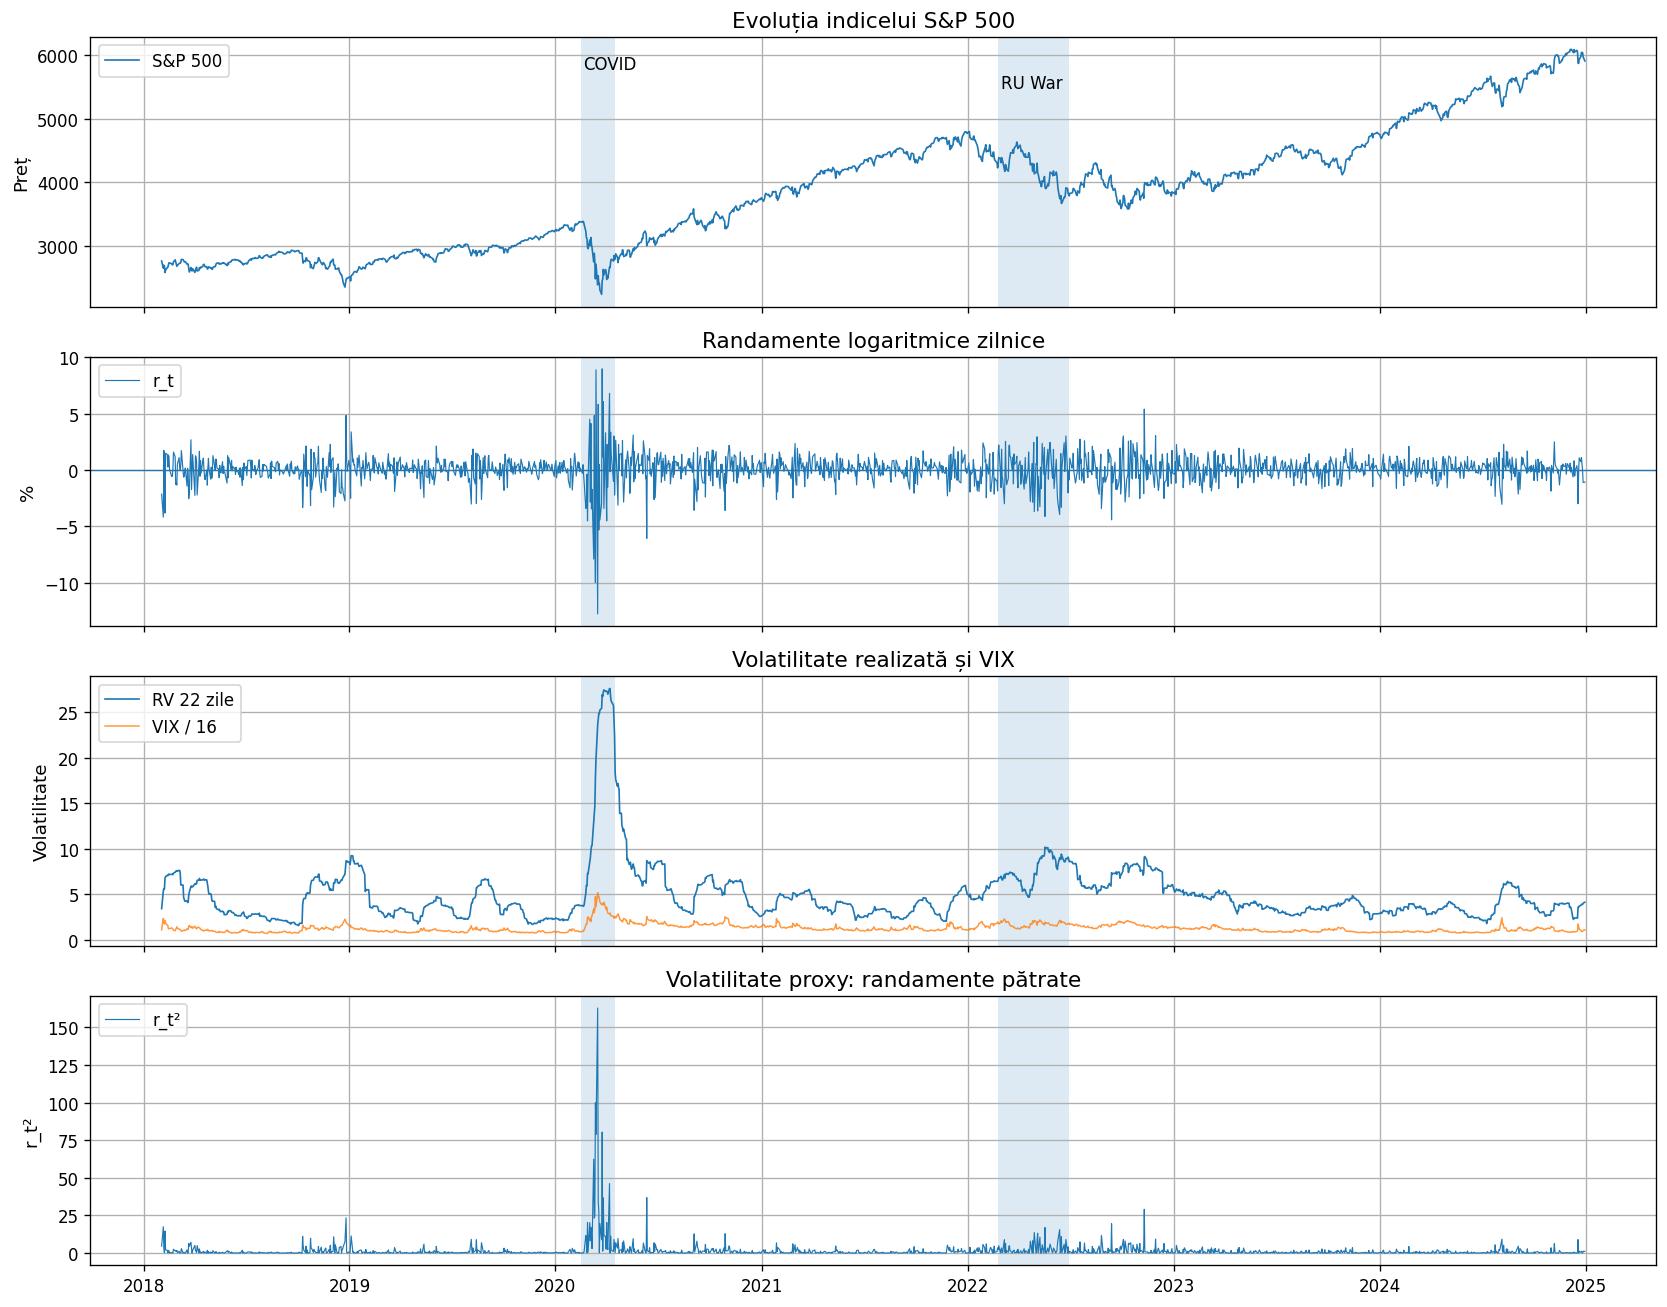

In [5]:
# ------------------------------------------------------------
# 2. EVOLUȚIE TEMPORALĂ
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(series.index, series[price_col], linewidth=1.0, label='S&P 500')
axes[0].set_title('Evoluția indicelui S&P 500')
axes[0].set_ylabel('Preț')
axes[0].legend(loc='upper left')

axes[1].plot(series.index, series['r_t'], linewidth=0.7, label='r_t')
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title('Randamente logaritmice zilnice')
axes[1].set_ylabel('%')
axes[1].legend(loc='upper left')

axes[2].plot(series.index, series['rv_22d'], linewidth=1.0, label='RV 22 zile')
if 'vix' in series.columns:
    axes[2].plot(series.index, series['vix'] / 16, linewidth=0.9, alpha=0.8, label='VIX / 16')
axes[2].set_title('Volatilitate realizată și VIX')
axes[2].set_ylabel('Volatilitate')
axes[2].legend(loc='upper left')

axes[3].plot(series.index, series['r_t_sq'], linewidth=0.7, label='r_t²')
axes[3].set_title('Volatilitate proxy: randamente pătrate')
axes[3].set_ylabel('r_t²')
axes[3].legend(loc='upper left')

# Perioade de criză
crisis_periods = [
    ('COVID crash', pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-15')),
    ('RU War shock', pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-30')),
]

for ax in axes:
    for label, start, end in crisis_periods:
        ax.axvspan(start, end, alpha=0.15)

# Etichete doar pe primul grafic
axes[0].text(pd.Timestamp('2020-02-20'), series[price_col].max()*0.95, 'COVID', fontsize=10)
axes[0].text(pd.Timestamp('2022-03-01'), series[price_col].max()*0.90, 'RU War', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '01_time_series_overview_crises.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.1. Specificarea seriilor și a obiectivului de prognoză

Analiza univariată urmărește să modeleze și să prognozeze seriile folosind doar informația trecută a aceleiași serii, fără sentiment.

Seriile principale sunt:

1. **Nivelul indicelui**: $P_t$, reprezentat de `adj_close` / `close`;
2. **Randamentul logaritmic**:  
   $$r_t = 100 \cdot [\ln(P_t) - \ln(P_{t-1})]$$
3. **Volatilitate proxy**:  
   $$r_t^2, \quad |r_t|, \quad RV_{22,t}$$

Modelele ARMA/ARIMA vizează în principal media condițională a randamentelor, iar modelele ARCH/GARCH vizează varianța condițională:

$$r_t = \mu_t + \varepsilon_t, \quad \varepsilon_t = z_t \sqrt{h_t}$$

$$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \beta h_{t-1}$$

## 3.2. Împărțirea train/test și metodologia de evaluare

Folosim o împărțire cronologică **70% train / 30% test**, fără shuffle, similară cu metodologia din Kim et al. (2023). Perioada de test este folosită pentru evaluarea out-of-sample.

Pentru interpretare, nu considerăm testul ca o singură prognoză pe termen lung, ci ca o evaluare a capacității predictive pe observații viitoare. În grafice vom afișa frecvent doar primele sau ultimele 30 zile din test pentru lizibilitate.

Split ratio: 70% train / 30% test
Train: 2018-02-02 → 2022-11-30 | n=1,216
Test:  2022-12-01 → 2024-12-30 | n=522
PLOT_WINDOW: 30 zile


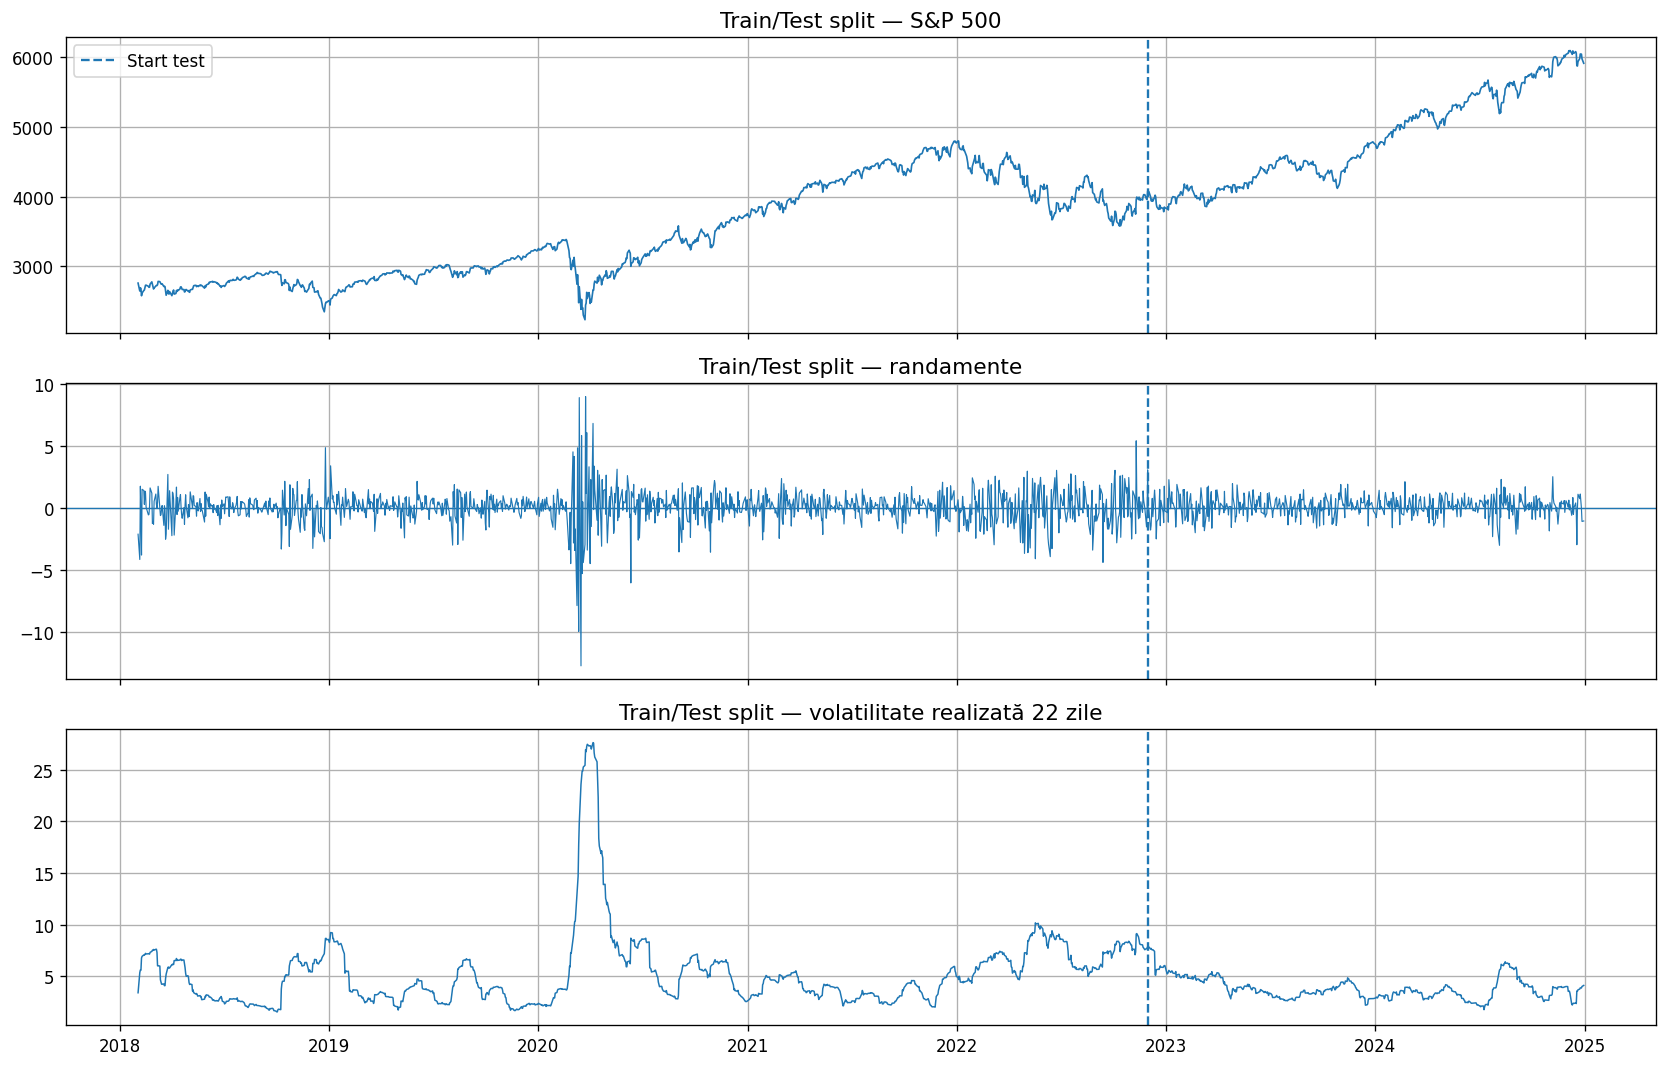

In [6]:
# ------------------------------------------------------------
# 3.2 TRAIN / TEST SPLIT
# ------------------------------------------------------------

split_idx = int(len(series) * SPLIT_RATIO)

train = series.iloc[:split_idx].copy()
test = series.iloc[split_idx:].copy()

print(f"Split ratio: {SPLIT_RATIO:.0%} train / {1-SPLIT_RATIO:.0%} test")
print(f"Train: {train.index.min().date()} → {train.index.max().date()} | n={len(train):,}")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} | n={len(test):,}")
print(f"PLOT_WINDOW: {PLOT_WINDOW} zile")

# Serii target
p_train, p_test = train[price_col], test[price_col]
r_train, r_test = train['r_t'], test['r_t']
rv_train, rv_test = train['rv_22d'], test['rv_22d']
var_train, var_test = train['r_t_sq'], test['r_t_sq']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(series.index, series[price_col], linewidth=1.0)
axes[0].axvline(test.index[0], linestyle='--', linewidth=1.4, label='Start test')
axes[0].set_title('Train/Test split — S&P 500')
axes[0].legend()

axes[1].plot(series.index, series['r_t'], linewidth=0.7)
axes[1].axvline(test.index[0], linestyle='--', linewidth=1.4)
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title('Train/Test split — randamente')

axes[2].plot(series.index, series['rv_22d'], linewidth=0.9)
axes[2].axvline(test.index[0], linestyle='--', linewidth=1.4)
axes[2].set_title('Train/Test split — volatilitate realizată 22 zile')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Funcții de evaluare

Folosim metrici separate pentru:

- **nivel / randamente**: MAE, RMSE, MAPE unde are sens, R²;
- **volatilitate**: MAE, RMSE și QLIKE.

QLIKE este util pentru evaluarea prognozelor de varianță, fiind frecvent folosit în literatura de volatilitate.

In [7]:
# ------------------------------------------------------------
# METRICS + HELPER FUNCTIONS
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def qlike(y_true_var, y_pred_var, eps=1e-8):
    y_true_var = np.maximum(np.asarray(y_true_var, dtype=float), eps)
    y_pred_var = np.maximum(np.asarray(y_pred_var, dtype=float), eps)
    return float(np.mean(np.log(y_pred_var) + y_true_var / y_pred_var))


def safe_r2(y_true, y_pred):
    try:
        return float(r2_score(y_true, y_pred))
    except Exception:
        return np.nan


def evaluate_point_forecast(name, y_true, y_pred, target, family):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred, index=y_true.index if len(y_true) == len(y_pred) else None).dropna()
    idx = y_true.index.intersection(y_pred.index)
    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]
    return {
        'model': name,
        'family': family,
        'target': target,
        'n_test': len(idx),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'R2': safe_r2(y_true, y_pred),
        'QLIKE': np.nan,
    }


def evaluate_variance_forecast(name, y_true_var, y_pred_var, target='r_t_sq', family='GARCH'):
    y_true = pd.Series(y_true_var).dropna()
    y_pred = pd.Series(y_pred_var).dropna()
    idx = y_true.index.intersection(y_pred.index)
    y_true = y_true.loc[idx]
    y_pred = y_pred.loc[idx]
    return {
        'model': name,
        'family': family,
        'target': target,
        'n_test': len(idx),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': np.nan,
        'R2': safe_r2(y_true, y_pred),
        'QLIKE': qlike(y_true, y_pred),
    }


def plot_forecast(y_train, y_test, y_pred, title, ylabel, filename, ci=None, window=PLOT_WINDOW):
    """Grafic forecast: ultimele 120 zile din train + primele `window` zile din test."""
    y_train_plot = y_train.iloc[-120:]
    y_test_plot = y_test.iloc[:window]
    y_pred = pd.Series(y_pred).copy()
    y_pred_plot = y_pred.loc[y_test_plot.index.intersection(y_pred.index)]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_train_plot.index, y_train_plot, label='train final', linewidth=1.0)
    ax.plot(y_test_plot.index, y_test_plot, label='test actual', linewidth=1.2)
    ax.plot(y_pred_plot.index, y_pred_plot, label='forecast', linewidth=1.2)
    ax.axvline(y_test.index[0], linestyle='--', linewidth=1.2, label='start test')

    if ci is not None:
        ci_plot = ci.loc[y_pred_plot.index]
        ax.fill_between(ci_plot.index, ci_plot.iloc[:, 0], ci_plot.iloc[:, 1], alpha=0.2, label='95% CI')

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


returns_results = []
price_results = []
rv_results = []
garch_results = []
model_info = []

## 3.3. Teste preliminare: staționaritate, ACF/PACF, Ljung-Box, ARCH-LM

Înainte de modelare, verificăm:

- dacă seriile sunt staționare;
- dacă există autocorelație în randamente;
- dacă există autocorelație în volatilitate proxy;
- dacă există efecte ARCH, adică heteroscedasticitate condițională.

In [8]:
# ------------------------------------------------------------
# 3.3 STATIONARITY TESTS
# ------------------------------------------------------------

def stationarity_tests(x, name):
    x = pd.Series(x).dropna()
    out = {'series': name, 'n': len(x)}

    # ADF: H0 = unit root / non-stationary
    adf_res = adfuller(x, autolag='AIC')
    out['ADF_stat'] = adf_res[0]
    out['ADF_pvalue'] = adf_res[1]
    out['ADF_decision_5pct'] = 'stationary' if adf_res[1] < 0.05 else 'non-stationary'

    # KPSS: H0 = stationary
    try:
        kpss_res = kpss(x, regression='c', nlags='auto')
        out['KPSS_stat'] = kpss_res[0]
        out['KPSS_pvalue'] = kpss_res[1]
        out['KPSS_decision_5pct'] = 'stationary' if kpss_res[1] > 0.05 else 'non-stationary'
    except Exception:
        out['KPSS_stat'] = np.nan
        out['KPSS_pvalue'] = np.nan
        out['KPSS_decision_5pct'] = 'error'

    # Phillips-Perron
    if ARCH_OK:
        try:
            pp = PhillipsPerron(x)
            out['PP_stat'] = pp.stat
            out['PP_pvalue'] = pp.pvalue
            out['PP_decision_5pct'] = 'stationary' if pp.pvalue < 0.05 else 'non-stationary'
        except Exception:
            out['PP_stat'] = np.nan
            out['PP_pvalue'] = np.nan
            out['PP_decision_5pct'] = 'error'
    else:
        out['PP_stat'] = np.nan
        out['PP_pvalue'] = np.nan
        out['PP_decision_5pct'] = 'not available'

    return out

stat_cols = [price_col, 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d']
if 'vix' in series.columns:
    stat_cols.append('vix')

stationarity_df = pd.DataFrame([stationarity_tests(train[c], c) for c in stat_cols])
stationarity_df = stationarity_df.set_index('series')
stationarity_df.round(4)

,n,ADF_stat,ADF_pvalue,ADF_decision_5pct,KPSS_stat,KPSS_pvalue,KPSS_decision_5pct,PP_stat,PP_pvalue,PP_decision_5pct
series,,,,,,,,,,
adj_close,1216,-1.2048,0.6715,non-stationary,4.9846,0.01,non-stationary,-1.1318,0.7022,non-stationary
r_t,1216,-10.6218,0.0000,stationary,0.0648,0.10,stationary,-41.5443,0.0000,stationary
r_t_sq,1216,-5.8928,0.0000,stationary,0.1195,0.10,stationary,-28.1065,0.0000,stationary
abs_r_t,1216,-5.3372,0.0000,stationary,0.2606,0.10,stationary,-34.0444,0.0000,stationary
rv_5d,1216,-4.5779,0.0001,stationary,0.2510,0.10,stationary,-5.5887,0.0000,stationary
rv_22d,1216,-2.8553,0.0508,non-stationary,0.2554,0.10,stationary,-3.8986,0.0020,stationary
vix,1216,-4.0276,0.0013,stationary,0.9491,0.01,non-stationary,-4.7403,0.0001,stationary


In [9]:
stationarity_df.to_csv(TABLE_DIR / '01_stationarity_tests.csv')
stationarity_df.to_latex(TABLE_DIR / '01_stationarity_tests.tex', float_format='%.4f')
print('Saved stationarity tests.')

Saved stationarity tests.


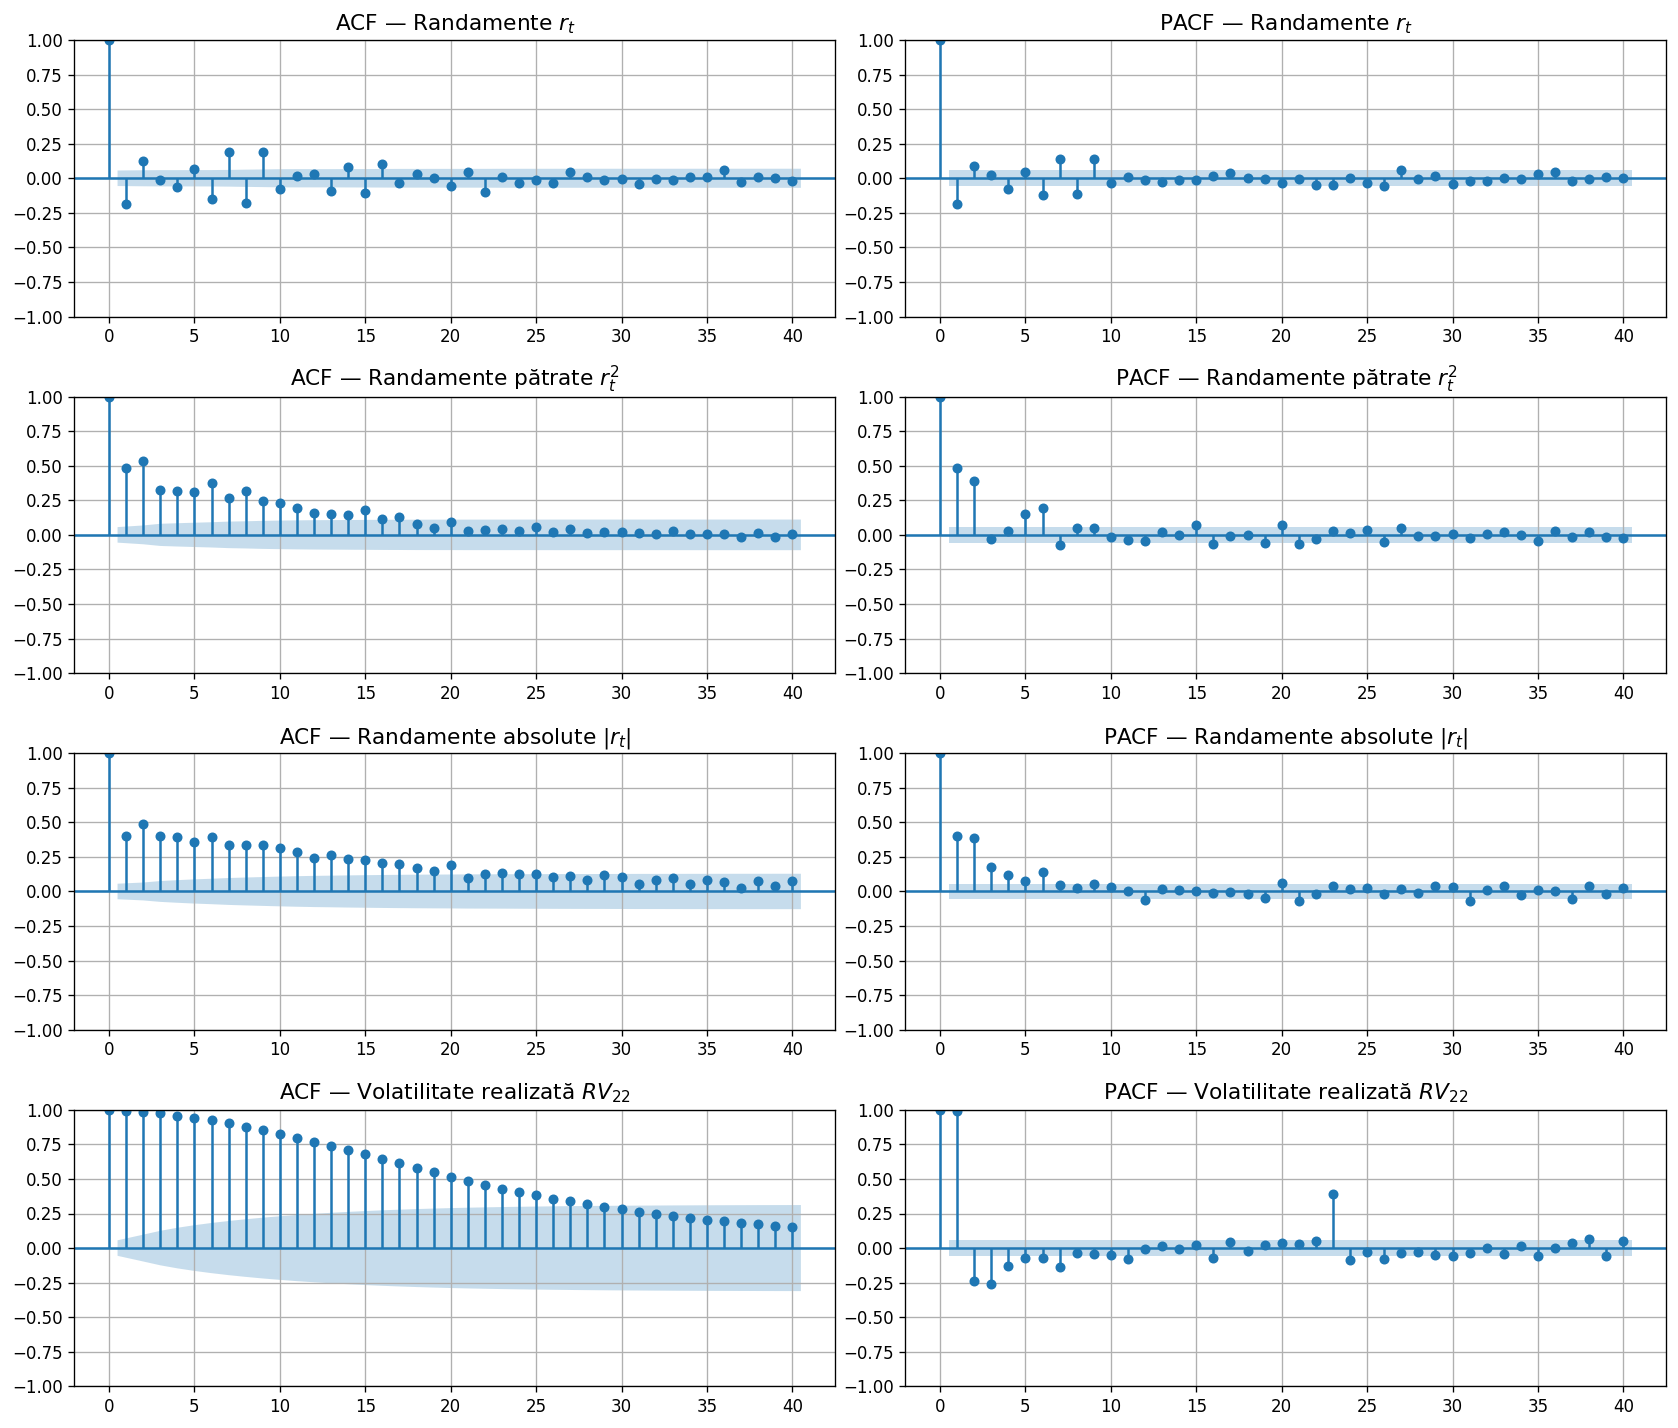

In [10]:
# ------------------------------------------------------------
# ACF / PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
acf_specs = [
    ('r_t', 'Randamente $r_t$'),
    ('r_t_sq', 'Randamente pătrate $r_t^2$'),
    ('abs_r_t', 'Randamente absolute $|r_t|$'),
    ('rv_22d', 'Volatilitate realizată $RV_{22}$'),
]

for row, (col, title) in enumerate(acf_specs):
    plot_acf(train[col].dropna(), lags=MAX_LAGS, ax=axes[row, 0], title=f'ACF — {title}')
    plot_pacf(train[col].dropna(), lags=MAX_LAGS, ax=axes[row, 1], title=f'PACF — {title}', method='ywm')

plt.tight_layout()
plt.savefig(FIG_DIR / '03_acf_pacf_preliminary.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ------------------------------------------------------------
# LJUNG-BOX + ARCH-LM
# ------------------------------------------------------------

lb_rows = []
for col in ['r_t', 'r_t_sq', 'abs_r_t', 'rv_22d']:
    x = train[col].dropna()
    lb = acorr_ljungbox(x, lags=[5, 10, 20], return_df=True)
    for lag, row in lb.iterrows():
        lb_rows.append({
            'series': col,
            'lag': lag,
            'LB_stat': row['lb_stat'],
            'LB_pvalue': row['lb_pvalue'],
            'decision_5pct': 'autocorrelation' if row['lb_pvalue'] < 0.05 else 'no autocorrelation'
        })

ljung_box_df = pd.DataFrame(lb_rows)
ljung_box_df.round(4)

,series,lag,LB_stat,LB_pvalue,decision_5pct
0,r_t,5,70.4413,0.0,autocorrelation
1,r_t,10,231.5206,0.0,autocorrelation
2,r_t,20,284.8404,0.0,autocorrelation
3,r_t_sq,5,1001.4325,0.0,autocorrelation
4,r_t_sq,10,1521.0807,0.0,autocorrelation
5,r_t_sq,20,1747.7661,0.0,autocorrelation
6,abs_r_t,5,1026.7136,0.0,autocorrelation
7,abs_r_t,10,1751.7940,0.0,autocorrelation
8,abs_r_t,20,2356.0154,0.0,autocorrelation
9,rv_22d,5,5753.7527,0.0,autocorrelation


In [12]:
ljung_box_df.to_csv(TABLE_DIR / '02_ljung_box_tests.csv', index=False)
ljung_box_df.to_latex(TABLE_DIR / '02_ljung_box_tests.tex', index=False, float_format='%.4f')

arch_lm = het_arch(r_train.dropna(), nlags=10)
arch_lm_df = pd.DataFrame({
    'test': ['ARCH-LM'],
    'LM_stat': [arch_lm[0]],
    'LM_pvalue': [arch_lm[1]],
    'F_stat': [arch_lm[2]],
    'F_pvalue': [arch_lm[3]],
    'decision_5pct': ['ARCH effects' if arch_lm[1] < 0.05 else 'no ARCH effects']
})
arch_lm_df.to_csv(TABLE_DIR / '03_arch_lm_test.csv', index=False)
arch_lm_df.round(6)

,test,LM_stat,LM_pvalue,F_stat,F_pvalue,decision_5pct
0,ARCH-LM,483.548937,0.0,79.983408,0.0,ARCH effects


## 3.4. Modele benchmark și netezire exponențială

Înainte de modelele avansate, construim benchmark-uri simple:

- **Mean forecast** pentru randamente;
- **Naive forecast** pentru randamente;
- **Random Walk** pentru nivelul indicelui;
- **Holt / ETS** pentru nivelul indicelui;
- **ETS** pentru volatilitatea realizată $RV_{22}$.

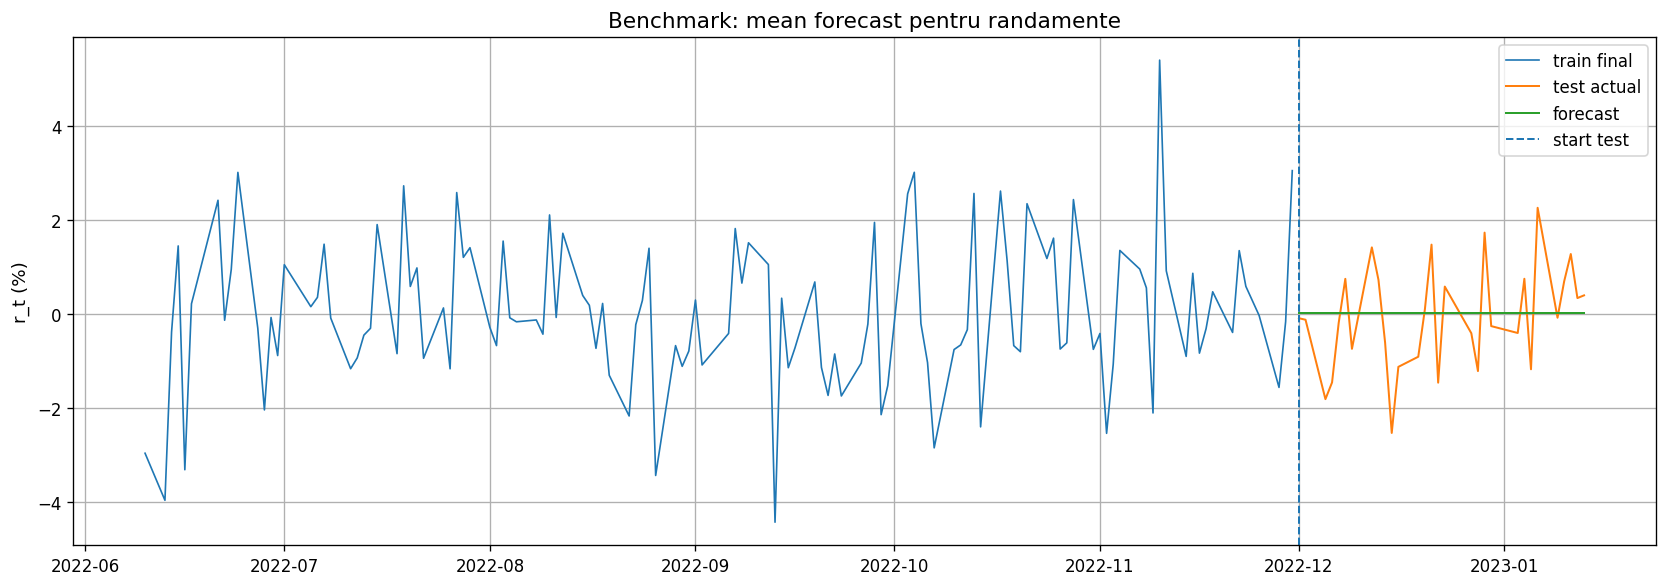

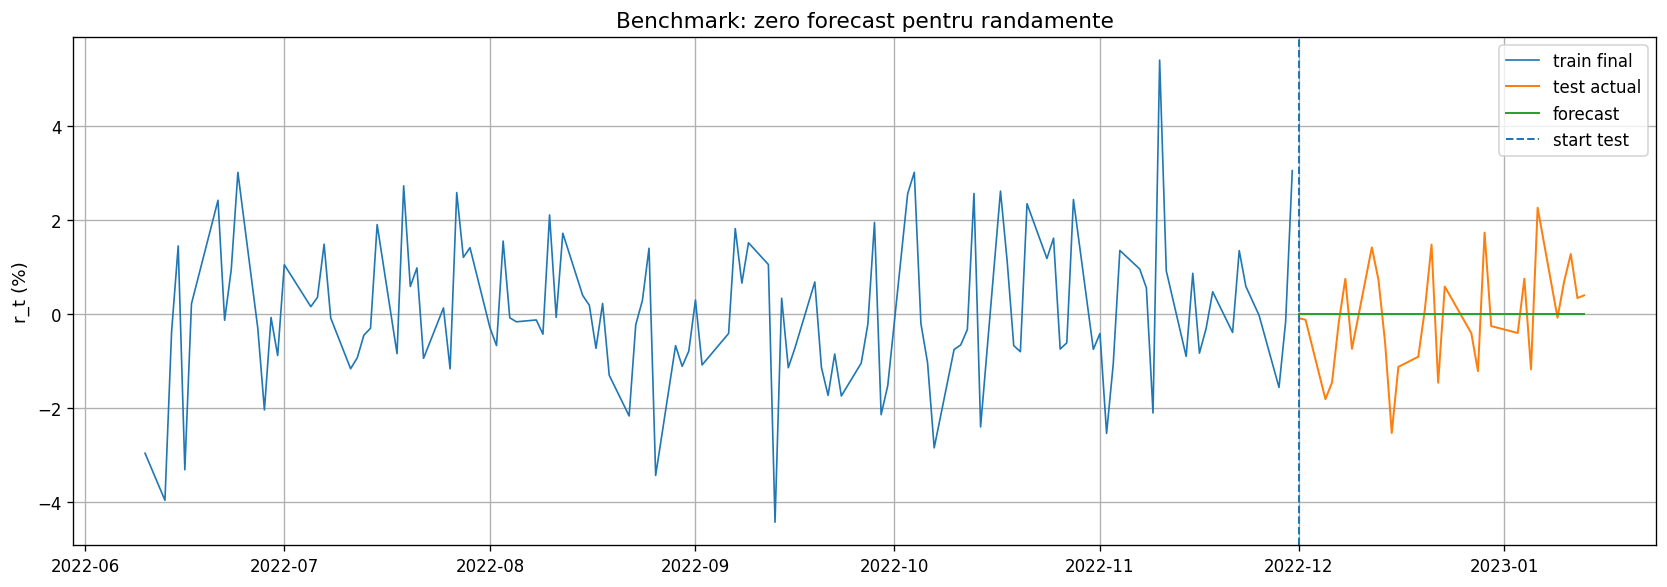

In [13]:
# ------------------------------------------------------------
# 3.4 BENCHMARKS — RETURNS
# ------------------------------------------------------------

# Mean forecast
mean_ret_pred = pd.Series(r_train.mean(), index=r_test.index, name='Mean')
returns_results.append(evaluate_point_forecast('Mean forecast', r_test, mean_ret_pred, 'r_t', 'Benchmark'))

# Naive: ultima valoare din train
naive_ret_pred = pd.Series(r_train.iloc[-1], index=r_test.index, name='Naive')
returns_results.append(evaluate_point_forecast('Naive last value', r_test, naive_ret_pred, 'r_t', 'Benchmark'))

# Zero forecast: des folosit pentru randamente financiare
zero_ret_pred = pd.Series(0.0, index=r_test.index, name='Zero')
returns_results.append(evaluate_point_forecast('Zero return forecast', r_test, zero_ret_pred, 'r_t', 'Benchmark'))

plot_forecast(
    r_train, r_test, mean_ret_pred,
    title='Benchmark: mean forecast pentru randamente',
    ylabel='r_t (%)',
    filename='04_benchmark_mean_returns.png'
)

plot_forecast(
    r_train, r_test, zero_ret_pred,
    title='Benchmark: zero forecast pentru randamente',
    ylabel='r_t (%)',
    filename='05_benchmark_zero_returns.png'
)

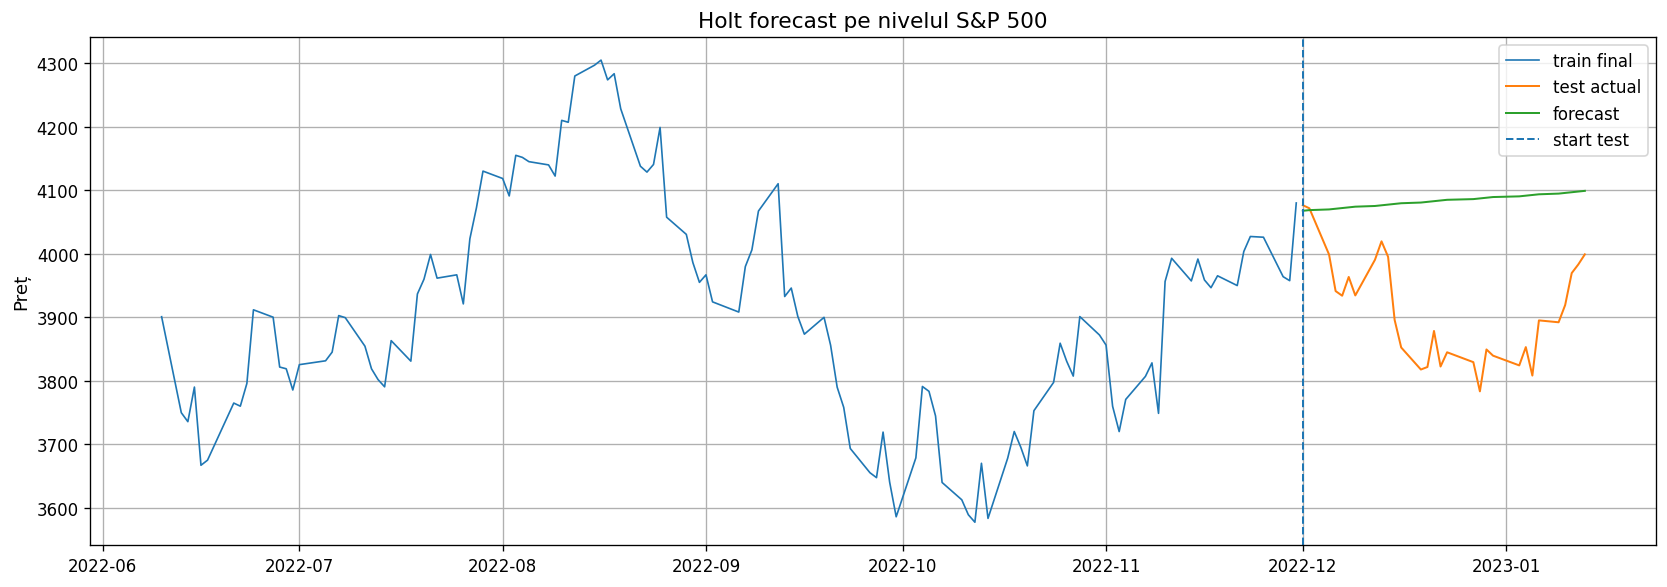

In [14]:
# ------------------------------------------------------------
# 3.4 BENCHMARKS — PRICE + ETS/HOLT
# ------------------------------------------------------------

# Random Walk pe preț: P_{t+h} = P_t
rw_price_pred = pd.Series(p_train.iloc[-1], index=p_test.index, name='RandomWalk')
price_results.append(evaluate_point_forecast('Random Walk price', p_test, rw_price_pred, price_col, 'Benchmark'))

# Holt additive trend pe preț
try:
    holt_price = Holt(p_train, initialization_method='estimated').fit(optimized=True)
    holt_price_pred = holt_price.forecast(len(p_test))
    holt_price_pred.index = p_test.index
    price_results.append(evaluate_point_forecast('Holt additive trend price', p_test, holt_price_pred, price_col, 'ETS'))
    model_info.append({'model': 'Holt price', 'AIC': getattr(holt_price, 'aic', np.nan), 'BIC': getattr(holt_price, 'bic', np.nan)})

    plot_forecast(
        p_train, p_test, holt_price_pred,
        title='Holt forecast pe nivelul S&P 500',
        ylabel='Preț',
        filename='06_holt_price_forecast.png'
    )
except Exception as e:
    print('Holt price failed:', e)

# ETS cu trend aditiv
try:
    ets_price = ExponentialSmoothing(
        p_train, trend='add', seasonal=None, initialization_method='estimated'
    ).fit(optimized=True)
    ets_price_pred = ets_price.forecast(len(p_test))
    ets_price_pred.index = p_test.index
    price_results.append(evaluate_point_forecast('ETS additive trend price', p_test, ets_price_pred, price_col, 'ETS'))
    model_info.append({'model': 'ETS price', 'AIC': getattr(ets_price, 'aic', np.nan), 'BIC': getattr(ets_price, 'bic', np.nan)})
except Exception as e:
    print('ETS price failed:', e)

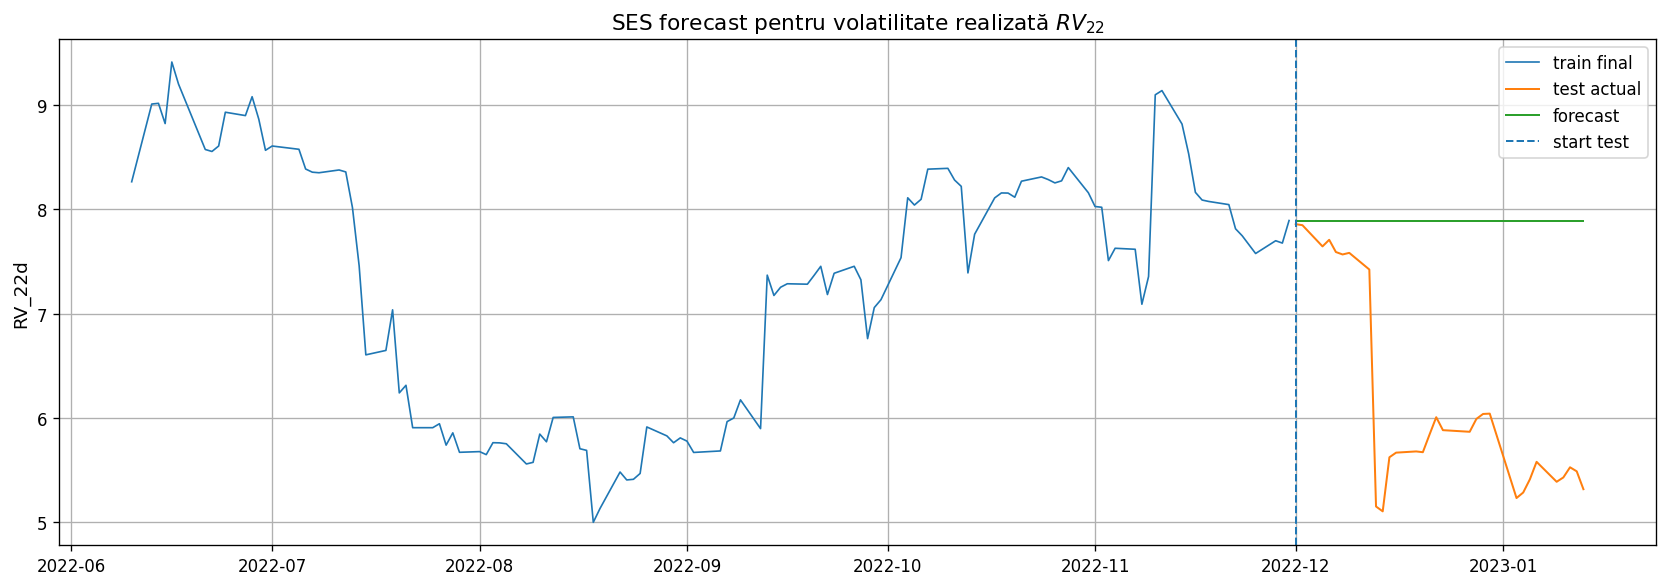

In [15]:
# ------------------------------------------------------------
# 3.4 ETS — REALIZED VOLATILITY RV_22D
# ------------------------------------------------------------

# Naive volatility forecast
naive_rv_pred = pd.Series(rv_train.iloc[-1], index=rv_test.index, name='Naive_RV')
rv_results.append(evaluate_point_forecast('Naive RV forecast', rv_test, naive_rv_pred, 'rv_22d', 'Benchmark'))

# Simple Exponential Smoothing pe RV
try:
    ses_rv = SimpleExpSmoothing(rv_train, initialization_method='estimated').fit(optimized=True)
    ses_rv_pred = ses_rv.forecast(len(rv_test))
    ses_rv_pred.index = rv_test.index
    rv_results.append(evaluate_point_forecast('SES RV_22d', rv_test, ses_rv_pred, 'rv_22d', 'ETS'))

    plot_forecast(
        rv_train, rv_test, ses_rv_pred,
        title='SES forecast pentru volatilitate realizată $RV_{22}$',
        ylabel='RV_22d',
        filename='07_ses_rv_forecast.png'
    )
except Exception as e:
    print('SES RV failed:', e)

# Holt pe RV, fără sezonalitate
try:
    holt_rv = Holt(rv_train, initialization_method='estimated').fit(optimized=True)
    holt_rv_pred = holt_rv.forecast(len(rv_test))
    holt_rv_pred.index = rv_test.index
    rv_results.append(evaluate_point_forecast('Holt RV_22d', rv_test, holt_rv_pred, 'rv_22d', 'ETS'))
except Exception as e:
    print('Holt RV failed:', e)

## 3.5. Modele ARMA/ARIMA/SARIMA

Pentru randamente, deoarece seria este de regulă staționară, modelul relevant este ARMA, adică ARIMA$(p,0,q)$.

Vom folosi:

1. `auto_arima`, dacă `pmdarima` este disponibil;
2. grid search manual după AIC/BIC ca fallback;
3. SARIMA cu perioadă 5 doar ca verificare a unei eventuale sezonalități săptămânale.

In [16]:
# ------------------------------------------------------------
# 3.5 AUTO-ARIMA / ARMA
# ------------------------------------------------------------

best_arima_order = None
best_arima_model = None
arima_search_table = None

if PMDARIMA_OK:
    print('Rulăm auto_arima pe randamente...')
    auto_model = auto_arima(
        r_train,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        d=0, seasonal=False,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )
    best_arima_order = auto_model.order
    print('auto_arima best order:', best_arima_order)
else:
    print('pmdarima indisponibil — folosim grid search manual.')

# Grid search manual pentru transparență
rows = []
fitted_arima = {}
for p in range(0, 6):
    for q in range(0, 6):
        if p == 0 and q == 0:
            continue
        try:
            fit = ARIMA(r_train, order=(p, 0, q)).fit()
            rows.append({'p': p, 'd': 0, 'q': q, 'AIC': fit.aic, 'BIC': fit.bic})
            fitted_arima[(p, 0, q)] = fit
        except Exception:
            pass

arima_search_table = pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)
arima_search_table.to_csv(TABLE_DIR / '04_arima_grid_search.csv', index=False)
arima_search_table.head(10)

Rulăm auto_arima pe randamente...
auto_arima best order: (4, 0, 2)


,p,d,q,AIC,BIC
0,5,0,5,4141.649562,4202.889427
1,4,0,5,4144.582250,4200.718793
2,2,0,2,4145.746838,4176.366771
3,2,0,5,4147.282656,4193.212555
4,3,0,3,4148.240862,4189.067439
5,2,0,4,4149.122415,4189.948991
6,4,0,2,4149.157613,4189.984189
7,3,0,4,4149.499781,4195.429679
8,4,0,3,4151.161339,4197.091238
9,5,0,3,4151.489947,4202.523167


                               SARIMAX Results                                
Dep. Variable:                    r_t   No. Observations:                 1216
Model:                 ARIMA(4, 0, 2)   Log Likelihood               -2066.579
Date:                Sat, 13 Jun 2026   AIC                           4149.158
Time:                        14:03:43   BIC                           4189.984
Sample:                             0   HQIC                          4164.527
                               - 1216                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0300      0.040      0.751      0.453      -0.048       0.108
ar.L1         -1.6916      0.067    -25.062      0.000      -1.824      -1.559
ar.L2         -0.8076      0.073    -11.002      0.0

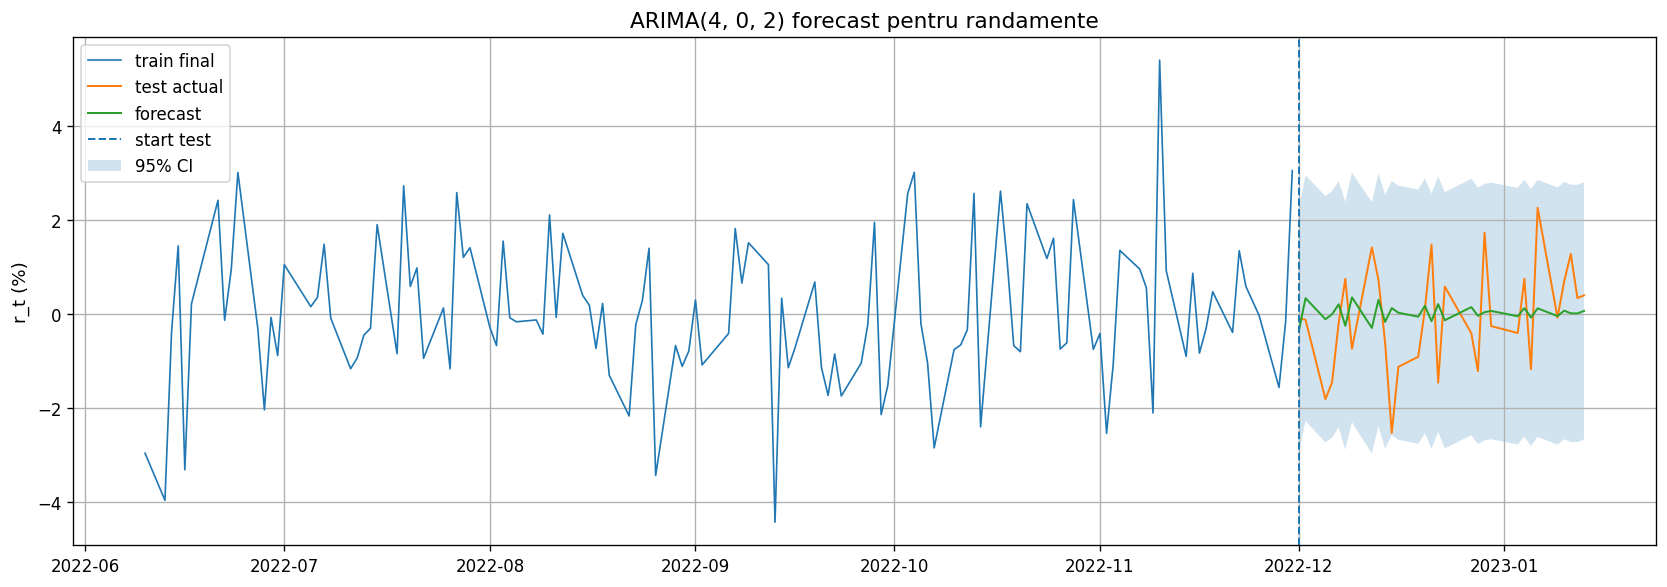

In [17]:
# Dacă auto_arima există, folosim ordinul ei; altfel, cel mai bun AIC din grid
if best_arima_order is None:
    best_arima_order = tuple(arima_search_table.iloc[0][['p', 'd', 'q']].astype(int))

best_arima_model = ARIMA(r_train, order=best_arima_order).fit()
print(best_arima_model.summary())

# Forecast direct pe perioada de test, pentru comparație out-of-sample
arima_fc = best_arima_model.get_forecast(steps=len(r_test))
arima_pred = arima_fc.predicted_mean
arima_pred.index = r_test.index
arima_ci = arima_fc.conf_int(alpha=0.05)
arima_ci.index = r_test.index

returns_results.append(evaluate_point_forecast(f'ARIMA{best_arima_order}', r_test, arima_pred, 'r_t', 'ARIMA'))
model_info.append({'model': f'ARIMA{best_arima_order}', 'AIC': best_arima_model.aic, 'BIC': best_arima_model.bic})

plot_forecast(
    r_train, r_test, arima_pred,
    title=f'ARIMA{best_arima_order} forecast pentru randamente',
    ylabel='r_t (%)',
    filename='08_arima_returns_forecast.png',
    ci=arima_ci
)

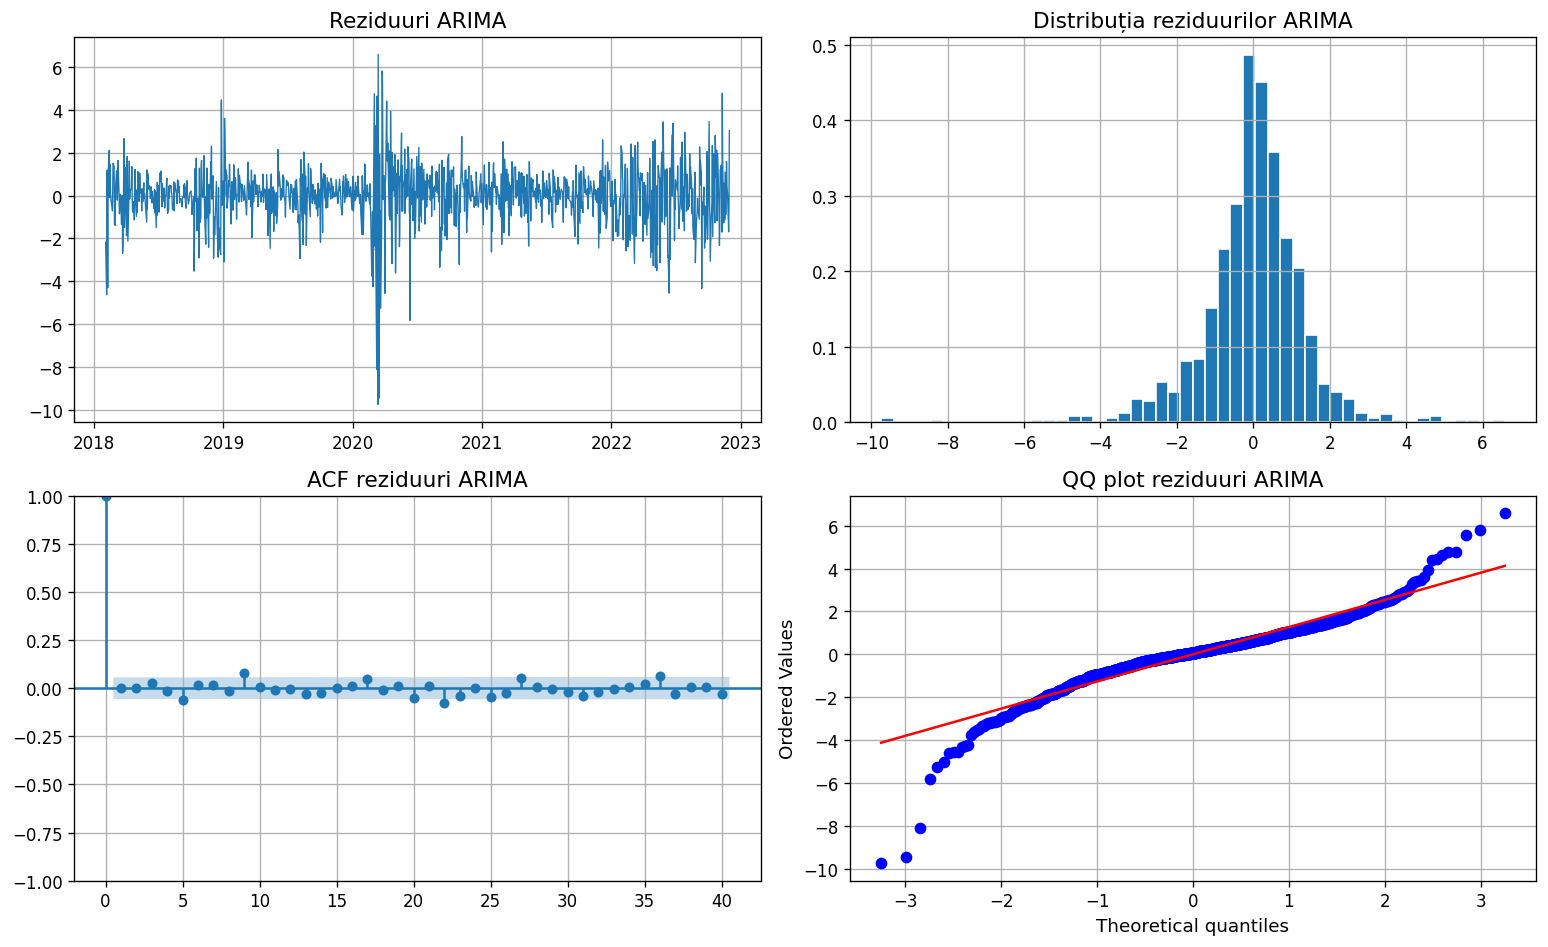

,test,pvalue,decision_5pct
0,Ljung-Box residuals lag 10,0.16111,do not reject H0
1,Ljung-Box squared residuals lag 10,0.00000,reject H0
2,ARCH-LM residuals,0.00000,reject H0


In [18]:
# ------------------------------------------------------------
# Diagnostic ARIMA
# ------------------------------------------------------------

arima_resid = best_arima_model.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(arima_resid, linewidth=0.8)
axes[0, 0].set_title('Reziduuri ARIMA')
axes[0, 1].hist(arima_resid, bins=50, density=True, edgecolor='white')
axes[0, 1].set_title('Distribuția reziduurilor ARIMA')
plot_acf(arima_resid, lags=MAX_LAGS, ax=axes[1, 0], title='ACF reziduuri ARIMA')
stats.probplot(arima_resid, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ plot reziduuri ARIMA')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_arima_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

arima_diag = pd.DataFrame({
    'test': ['Ljung-Box residuals lag 10', 'Ljung-Box squared residuals lag 10', 'ARCH-LM residuals'],
    'pvalue': [
        acorr_ljungbox(arima_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        acorr_ljungbox(arima_resid**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        het_arch(arima_resid, nlags=10)[1]
    ]
})
arima_diag['decision_5pct'] = np.where(arima_diag['pvalue'] < 0.05, 'reject H0', 'do not reject H0')
arima_diag.to_csv(TABLE_DIR / '05_arima_diagnostics.csv', index=False)
arima_diag.round(6)

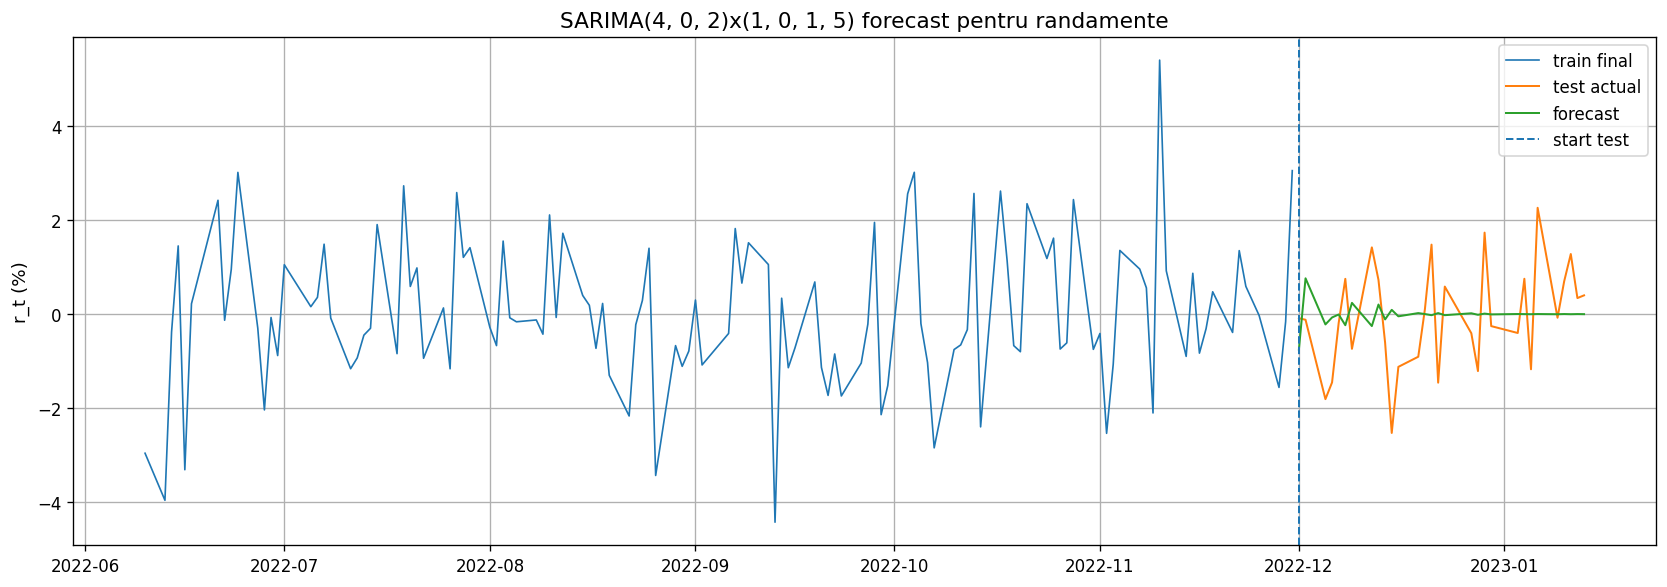

                                      SARIMAX Results                                      
Dep. Variable:                                 r_t   No. Observations:                 1216
Model:             SARIMAX(4, 0, 2)x(1, 0, [1], 5)   Log Likelihood               -2049.972
Date:                             Sat, 13 Jun 2026   AIC                           4117.944
Time:                                     14:03:45   BIC                           4163.807
Sample:                                          0   HQIC                          4135.215
                                            - 1216                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7000      0.258     -2.713      0.007      -1.206      -0.194
ar.L2          0.3016      

In [19]:
# ------------------------------------------------------------
# SARIMA: verificare sezonalitate săptămânală s=5
# ------------------------------------------------------------

try:
    sarima_order = best_arima_order
    seasonal_order = (1, 0, 1, SEASONAL_PERIOD)
    sarima_model = SARIMAX(
        r_train,
        order=sarima_order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarima_fc = sarima_model.get_forecast(steps=len(r_test))
    sarima_pred = sarima_fc.predicted_mean
    sarima_pred.index = r_test.index

    returns_results.append(evaluate_point_forecast(
        f'SARIMA{sarima_order}x{seasonal_order}', r_test, sarima_pred, 'r_t', 'SARIMA'
    ))
    model_info.append({
        'model': f'SARIMA{sarima_order}x{seasonal_order}',
        'AIC': sarima_model.aic,
        'BIC': sarima_model.bic
    })

    plot_forecast(
        r_train, r_test, sarima_pred,
        title=f'SARIMA{sarima_order}x{seasonal_order} forecast pentru randamente',
        ylabel='r_t (%)',
        filename='10_sarima_returns_forecast.png'
    )
    print(sarima_model.summary())
except Exception as e:
    print('SARIMA nu a putut fi estimat:', e)

## 3.6. Persistență și memorie lungă: verificare ARFIMA

ARFIMA este relevant dacă există memorie lungă, adică autocorelații care se sting lent. În Python, estimarea ARFIMA nu este la fel de standard ca ARIMA/GARCH, deci tratăm această secțiune ca o verificare exploratorie.

Calculăm exponentul Hurst pentru randamente și pentru proxy-urile de volatilitate. Valori peste 0.5 pot indica persistență, dar interpretarea trebuie făcută prudent.

In [20]:
# ------------------------------------------------------------
# 3.6 LONG MEMORY / HURST
# ------------------------------------------------------------

def hurst_rs(series, min_window=10, max_window=None, num_windows=20):
    """Estimare simplă Hurst prin metoda R/S. Interpretare exploratorie."""
    x = pd.Series(series).dropna().values
    n = len(x)
    if max_window is None:
        max_window = n // 4
    windows = np.unique(np.logspace(np.log10(min_window), np.log10(max_window), num_windows).astype(int))
    rs_vals = []
    valid_windows = []
    for w in windows:
        if w < 10 or w >= n:
            continue
        chunks = n // w
        rs_chunk = []
        for i in range(chunks):
            chunk = x[i*w:(i+1)*w]
            chunk = chunk - chunk.mean()
            z = np.cumsum(chunk)
            R = z.max() - z.min()
            S = chunk.std(ddof=1)
            if S > 0:
                rs_chunk.append(R / S)
        if len(rs_chunk) > 0:
            rs_vals.append(np.mean(rs_chunk))
            valid_windows.append(w)
    if len(rs_vals) < 2:
        return np.nan, None
    slope, intercept = np.polyfit(np.log(valid_windows), np.log(rs_vals), 1)
    return slope, pd.DataFrame({'window': valid_windows, 'RS': rs_vals})

hurst_rows = []
for col in ['r_t', 'r_t_sq', 'abs_r_t', 'rv_22d']:
    H, rs_df = hurst_rs(train[col])
    hurst_rows.append({
        'series': col,
        'Hurst_RS': H,
        'interpretation': 'persistent / long-memory indication' if H > 0.55 else ('anti-persistent' if H < 0.45 else 'near random walk')
    })

hurst_df = pd.DataFrame(hurst_rows).set_index('series')
hurst_df.to_csv(TABLE_DIR / '06_hurst_long_memory.csv')
hurst_df.round(4)

,Hurst_RS,interpretation
series,,
r_t,0.5462,near random walk
r_t_sq,0.8251,persistent / long-memory indication
abs_r_t,0.8724,persistent / long-memory indication
rv_22d,0.9752,persistent / long-memory indication


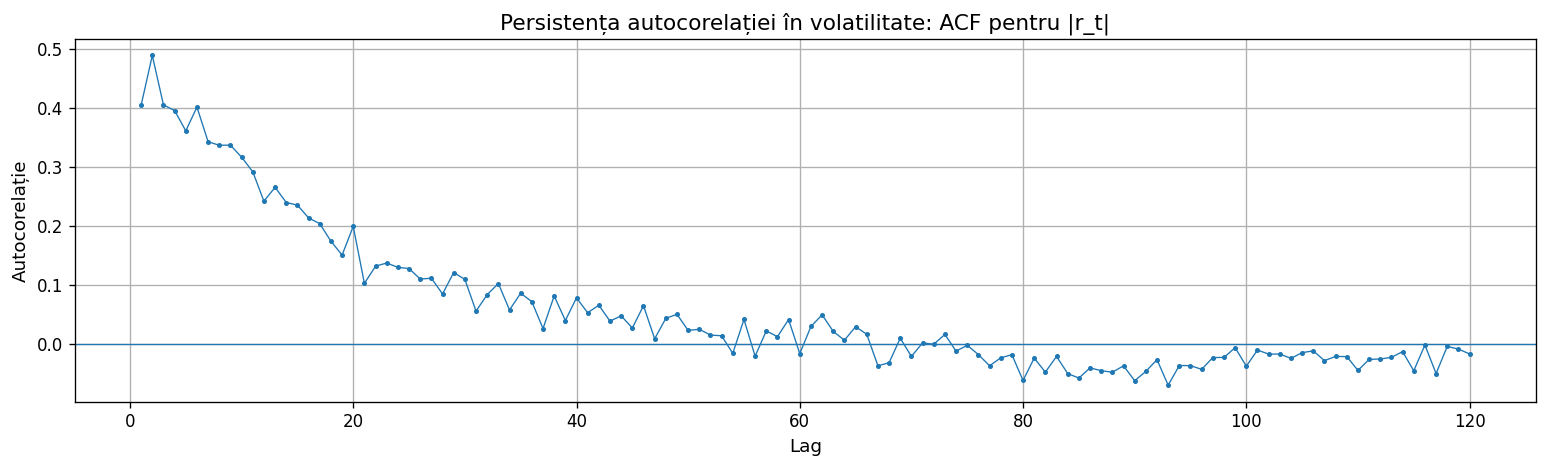

In [21]:
# Grafic ACF pentru volatilitate pe mai multe laguri — verificare vizuală persistență
fig, ax = plt.subplots(figsize=(13, 4))
acf_vals = [train['abs_r_t'].autocorr(lag=i) for i in range(1, 121)]
ax.plot(range(1, 121), acf_vals, marker='o', markersize=2, linewidth=0.8)
ax.axhline(0, linewidth=0.8)
ax.set_title('Persistența autocorelației în volatilitate: ACF pentru |r_t|')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorelație')
plt.tight_layout()
plt.savefig(FIG_DIR / '11_long_memory_acf_abs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7. Modele ARCH/GARCH și extensii

Aceasta este secțiunea centrală pentru tema proiectului, deoarece obiectivul principal este modelarea și prognoza volatilității.

Estimăm:

- ARCH(1);
- GARCH(1,1);
- GARCH(1,1) cu distribuție t-Student;
- EGARCH(1,1);
- GJR-GARCH(1,1), numit uneori TGARCH.

Pentru comparația forecast-urilor de varianță, folosim $r_t^2$ ca proxy pentru volatilitatea observată.

In [22]:
# ------------------------------------------------------------
# 3.7 GARCH FAMILY — ESTIMATION
# ------------------------------------------------------------

if not ARCH_OK:
    print("Pachetul arch nu este disponibil; sari peste secțiunea GARCH.")
else:
    garch_specs = [
        ('ARCH(1)',       {'mean': 'Constant', 'vol': 'ARCH',   'p': 1, 'dist': 'normal'}),
        ('GARCH(1,1)',    {'mean': 'Constant', 'vol': 'GARCH',  'p': 1, 'q': 1, 'dist': 'normal'}),
        ('GARCH(1,1)-t',  {'mean': 'Constant', 'vol': 'GARCH',  'p': 1, 'q': 1, 'dist': 't'}),
        ('EGARCH(1,1)-t', {'mean': 'Constant', 'vol': 'EGARCH', 'p': 1, 'q': 1, 'dist': 't'}),
        ('GJR-GARCH(1,1)-t', {'mean': 'Constant', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}),
    ]

    garch_fits = {}
    garch_est_rows = []

    for name, spec in garch_specs:
        try:
            am = arch_model(r_train, rescale=False, **spec)
            fit = am.fit(disp='off')
            garch_fits[name] = fit

            params = fit.params.to_dict()
            alpha = params.get('alpha[1]', np.nan)
            beta = params.get('beta[1]', np.nan)
            gamma = params.get('gamma[1]', np.nan)

            if 'GJR' in name and not np.isnan(gamma):
                persistence = alpha + beta + gamma / 2
                persistence_type = 'alpha + beta + gamma/2'
            elif 'EGARCH' in name:
                persistence = beta
                persistence_type = 'beta in log-variance equation'
            else:
                persistence = alpha + beta if not np.isnan(beta) else alpha
                persistence_type = 'alpha + beta'

            garch_est_rows.append({
                'model': name,
                'AIC': fit.aic,
                'BIC': fit.bic,
                'LogLik': fit.loglikelihood,
                'omega': params.get('omega', np.nan),
                'alpha[1]': alpha,
                'beta[1]': beta,
                'gamma[1]': gamma,
                'nu': params.get('nu', np.nan),
                'persistence': persistence,
                'persistence_type': persistence_type,
            })
        except Exception as e:
            print(f'{name} failed: {e}')

    garch_est_df = pd.DataFrame(garch_est_rows).sort_values('AIC').reset_index(drop=True)
    garch_est_df.to_csv(TABLE_DIR / '07_garch_estimation_comparison.csv', index=False)
    display(garch_est_df.round(4))

,model,AIC,BIC,LogLik,omega,alpha[1],beta[1],gamma[1],nu,persistence,persistence_type
0,"GJR-GARCH(1,1)-t",3471.5156,3502.1356,-1729.7578,0.0301,0.0322,0.8213,0.2653,6.0246,0.9862,alpha + beta + gamma/2
1,"GARCH(1,1)-t",3501.1220,3526.6386,-1745.5610,0.0306,0.2016,0.7984,NaN,6.0170,1.0000,alpha + beta
2,"EGARCH(1,1)-t",3511.2978,3536.8144,-1750.6489,0.0215,0.3817,0.9649,NaN,5.9198,0.9649,beta in log-variance equation
3,"GARCH(1,1)",3573.8574,3594.2707,-1782.9287,0.0489,0.2169,0.7672,NaN,NaN,0.9842,alpha + beta
4,ARCH(1),3904.5400,3919.8500,-1949.2700,0.9150,0.5881,NaN,NaN,NaN,0.5881,alpha + beta


In [23]:
# Summary pentru cel mai bun GARCH după AIC
if ARCH_OK and len(garch_fits) > 0:
    best_garch_name = garch_est_df.iloc[0]['model']
    best_garch_fit = garch_fits[best_garch_name]
    print('Best GARCH by AIC:', best_garch_name)
    print(best_garch_fit.summary())

Best GARCH by AIC: GJR-GARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                          r_t   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -1729.76
Distribution:      Standardized Student's t   AIC:                           3471.52
Method:                  Maximum Likelihood   BIC:                           3502.14
                                              No. Observations:                 1216
Date:                      Sat, Jun 13 2026   Df Residuals:                     1215
Time:                              14:03:45   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------

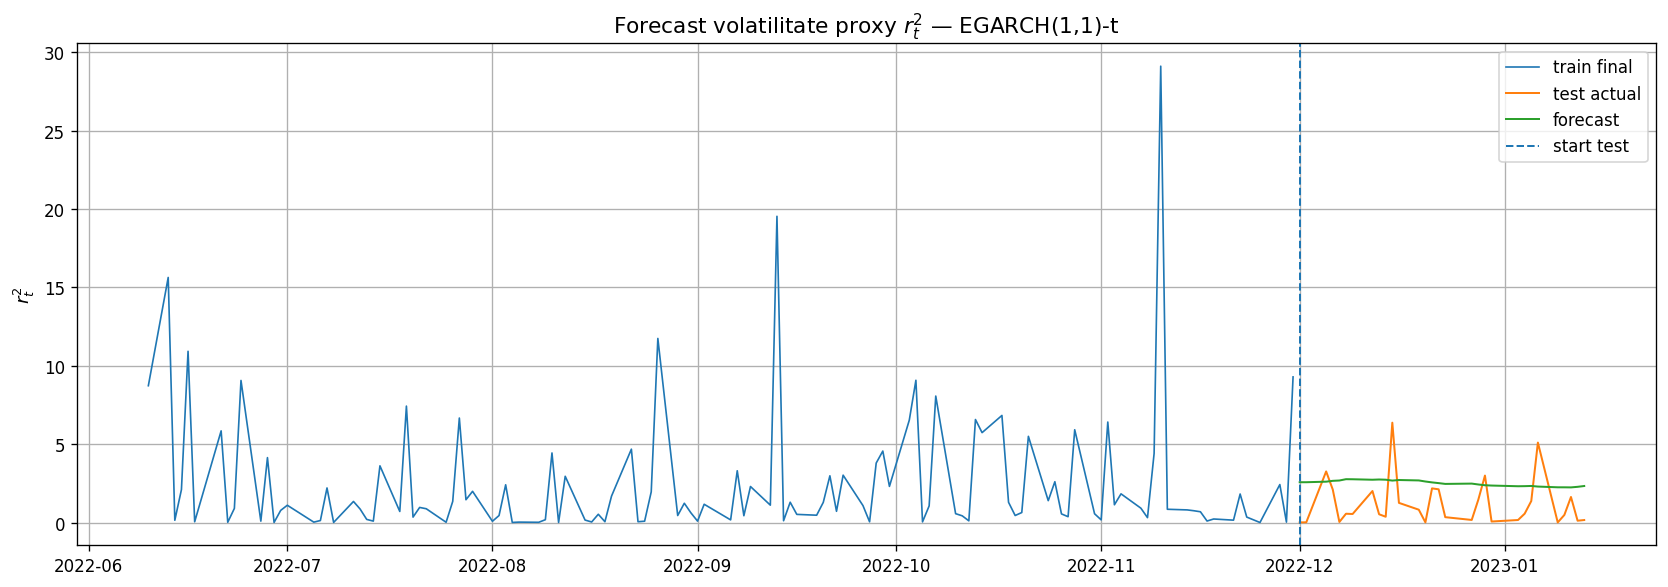

In [24]:
# ------------------------------------------------------------
# 3.7 GARCH FORECASTS
# ------------------------------------------------------------
# Pentru modelele cu forecast multi-step analitic indisponibil, încercăm simulation.
# Evaluarea se face pe întreaga perioadă de test față de r_t^2.

if ARCH_OK and len(garch_fits) > 0:
    garch_var_forecasts = {}

    for name, fit in garch_fits.items():
        try:
            fc = fit.forecast(horizon=len(r_test), reindex=False)
            var_pred = pd.Series(fc.variance.values[-1], index=r_test.index, name=name)
        except Exception as e1:
            try:
                fc = fit.forecast(horizon=len(r_test), method='simulation', simulations=1000, reindex=False)
                var_pred = pd.Series(fc.variance.values[-1], index=r_test.index, name=name)
            except Exception as e2:
                print(f'{name}: forecast failed | analytic: {e1} | simulation: {e2}')
                continue

        # Forțăm pozitivitatea
        var_pred = var_pred.clip(lower=1e-8)
        garch_var_forecasts[name] = var_pred
        garch_results.append(evaluate_variance_forecast(name, var_test, var_pred, 'r_t_sq', 'GARCH'))

    # Grafic pentru cel mai bun model după QLIKE, dacă există
    if len(garch_results) > 0:
        garch_results_df_temp = pd.DataFrame(garch_results).sort_values('QLIKE')
        best_garch_forecast_name = garch_results_df_temp.iloc[0]['model']
        best_var_pred = garch_var_forecasts[best_garch_forecast_name]

        plot_forecast(
            var_train, var_test, best_var_pred,
            title=f'Forecast volatilitate proxy $r_t^2$ — {best_garch_forecast_name}',
            ylabel='$r_t^2$',
            filename='12_best_garch_variance_forecast.png'
        )

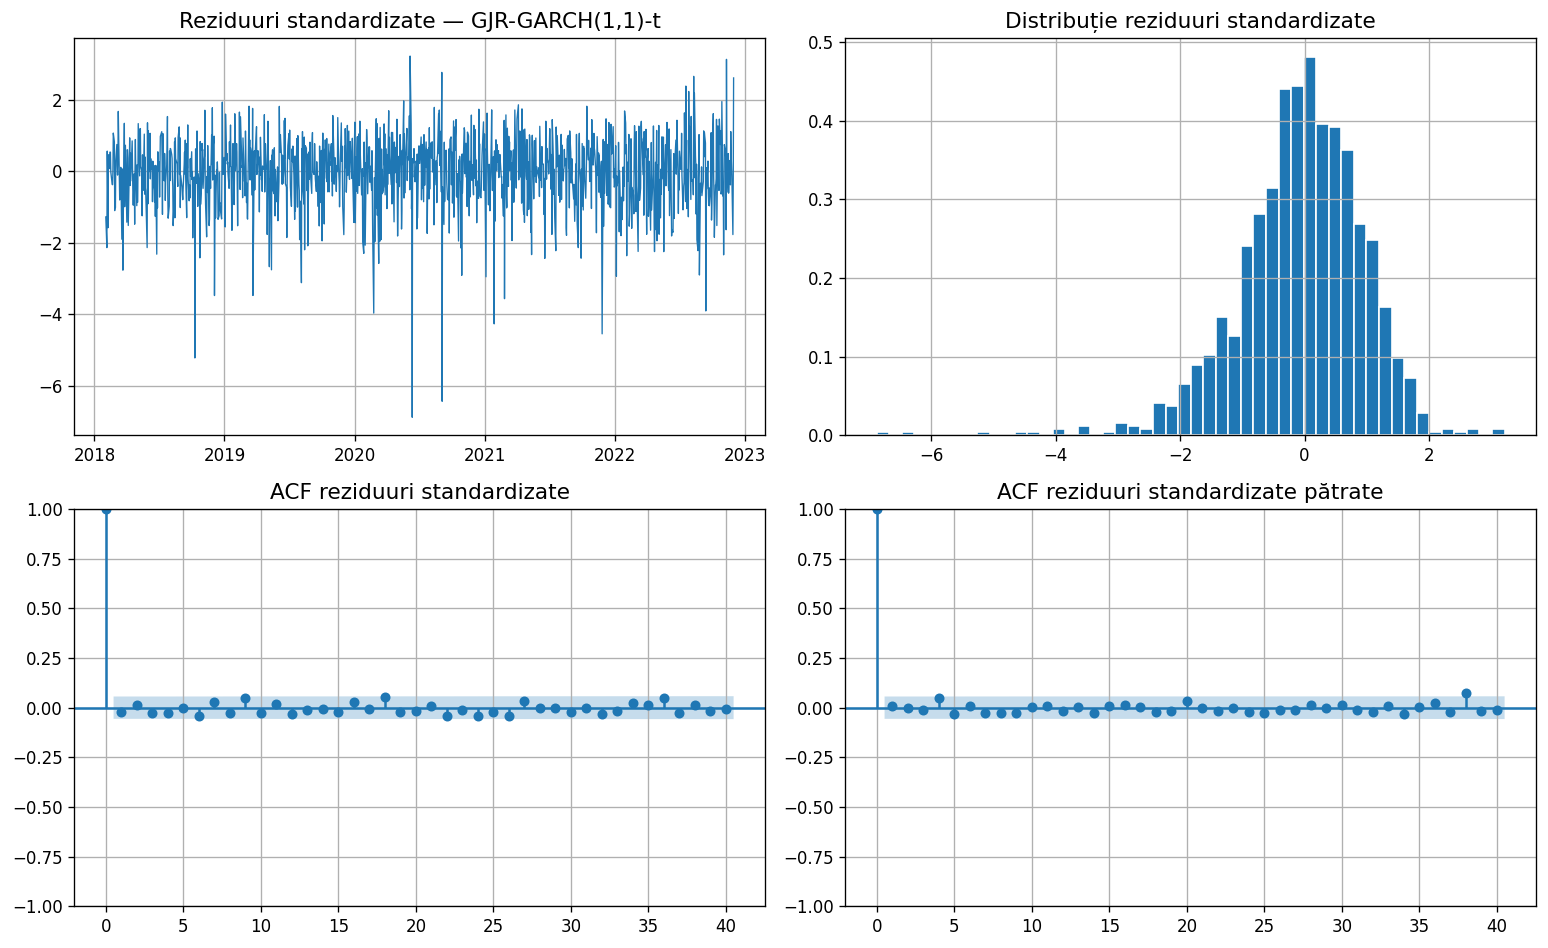

,test,pvalue,decision_5pct
0,Ljung-Box std resid lag 10,0.396292,do not reject H0
1,Ljung-Box std resid^2 lag 10,0.744954,do not reject H0


In [25]:
# Diagnostic reziduuri standardizate pentru cel mai bun GARCH după AIC
if ARCH_OK and len(garch_fits) > 0:
    std_resid = best_garch_fit.std_resid.dropna()

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes[0, 0].plot(std_resid, linewidth=0.8)
    axes[0, 0].set_title(f'Reziduuri standardizate — {best_garch_name}')
    axes[0, 1].hist(std_resid, bins=50, density=True, edgecolor='white')
    axes[0, 1].set_title('Distribuție reziduuri standardizate')
    plot_acf(std_resid, lags=MAX_LAGS, ax=axes[1, 0], title='ACF reziduuri standardizate')
    plot_acf(std_resid**2, lags=MAX_LAGS, ax=axes[1, 1], title='ACF reziduuri standardizate pătrate')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '13_garch_standardized_residuals.png', dpi=150, bbox_inches='tight')
    plt.show()

    garch_diag_df = pd.DataFrame({
        'test': ['Ljung-Box std resid lag 10', 'Ljung-Box std resid^2 lag 10'],
        'pvalue': [
            acorr_ljungbox(std_resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
            acorr_ljungbox(std_resid**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0],
        ]
    })
    garch_diag_df['decision_5pct'] = np.where(garch_diag_df['pvalue'] < 0.05, 'reject H0', 'do not reject H0')
    garch_diag_df.to_csv(TABLE_DIR / '08_garch_residual_diagnostics.csv', index=False)
    display(garch_diag_df.round(6))

## 3.8. Modele State Space și filtrul Kalman

Modelele în spațiul stărilor permit estimarea unor componente latente, precum nivelul și trendul. În contextul nostru, aplicăm:

1. model local linear trend pe log-preț;
2. model local level pe volatilitatea realizată $RV_{22}$.

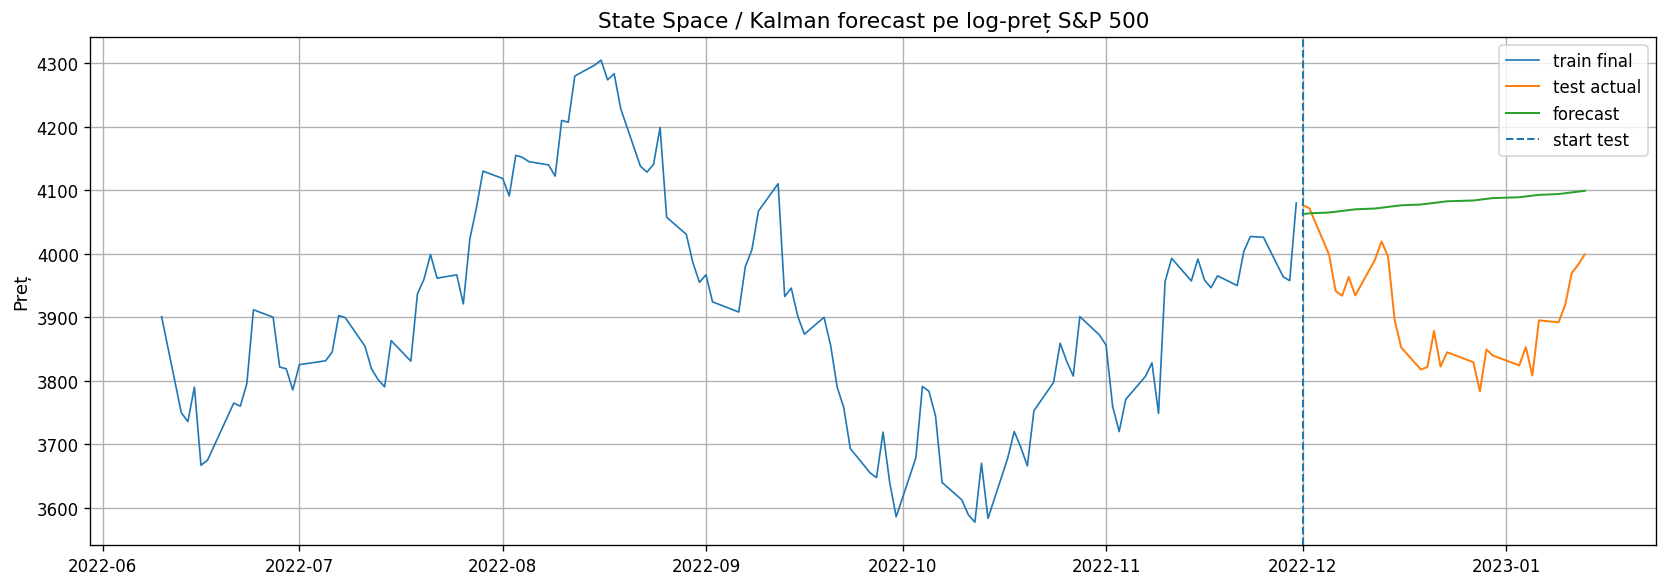

                        Unobserved Components Results                         
Dep. Variable:              adj_close   No. Observations:                 1216
Model:             local linear trend   Log Likelihood                3477.307
Date:                Sat, 13 Jun 2026   AIC                          -6948.615
Time:                        14:03:46   BIC                          -6933.310
Sample:                             0   HQIC                         -6942.853
                               - 1216                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  2.974e-05    2.4e-06     12.379      0.000     2.5e-05    3.44e-05
sigma2.level         0.0001   5.28e-06     25.479      0.000       0.000       0.000
sigma2.trend       2.05e-11 

In [26]:
# ------------------------------------------------------------
# 3.8 STATE SPACE — LOG PRICE
# ------------------------------------------------------------

log_p_train = np.log(p_train)
log_p_test = np.log(p_test)

try:
    ss_price = UnobservedComponents(log_p_train, level='local linear trend').fit(disp=False)
    ss_price_fc = ss_price.get_forecast(steps=len(log_p_test))
    ss_log_pred = ss_price_fc.predicted_mean
    ss_log_pred.index = log_p_test.index
    ss_price_pred = np.exp(ss_log_pred)
    ss_price_pred.index = p_test.index

    price_results.append(evaluate_point_forecast('State Space local linear trend price', p_test, ss_price_pred, price_col, 'State Space'))
    model_info.append({'model': 'State Space price', 'AIC': ss_price.aic, 'BIC': ss_price.bic})

    plot_forecast(
        p_train, p_test, ss_price_pred,
        title='State Space / Kalman forecast pe log-preț S&P 500',
        ylabel='Preț',
        filename='14_state_space_price_forecast.png'
    )

    print(ss_price.summary())
except Exception as e:
    print('State Space price failed:', e)

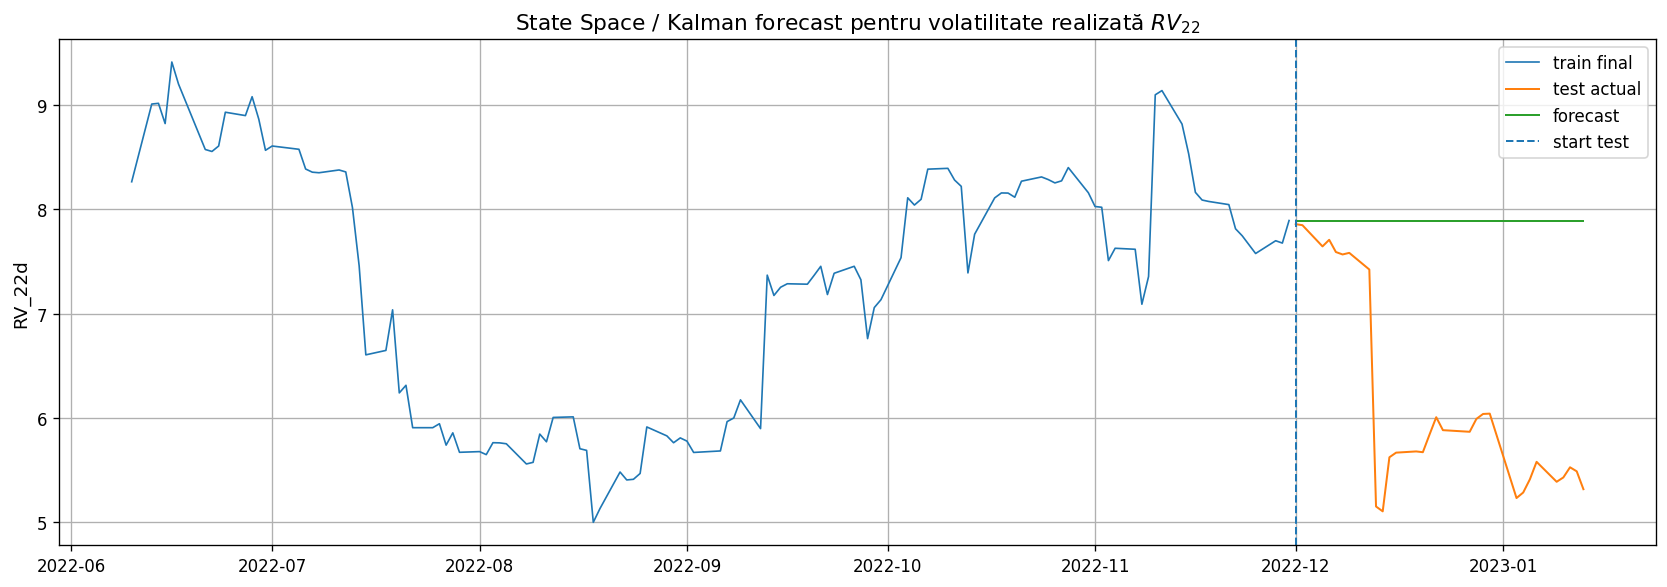

                        Unobserved Components Results                         
Dep. Variable:                 rv_22d   No. Observations:                 1216
Model:                    local level   Log Likelihood                -591.558
Date:                Sat, 13 Jun 2026   AIC                           1187.115
Time:                        14:03:46   BIC                           1197.320
Sample:                             0   HQIC                          1190.957
                               - 1216                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  5.746e-12      0.002   2.36e-09      1.000      -0.005       0.005
sigma2.level         0.1550      0.004     42.535      0.000       0.148       0.162
Ljung-Box (L1) (Q):         

In [27]:
# ------------------------------------------------------------
# 3.8 STATE SPACE — RV_22D
# ------------------------------------------------------------

try:
    ss_rv = UnobservedComponents(rv_train, level='local level').fit(disp=False)
    ss_rv_fc = ss_rv.get_forecast(steps=len(rv_test))
    ss_rv_pred = ss_rv_fc.predicted_mean
    ss_rv_pred.index = rv_test.index
    ss_rv_pred = ss_rv_pred.clip(lower=0)

    rv_results.append(evaluate_point_forecast('State Space local level RV_22d', rv_test, ss_rv_pred, 'rv_22d', 'State Space'))
    model_info.append({'model': 'State Space RV_22d', 'AIC': ss_rv.aic, 'BIC': ss_rv.bic})

    plot_forecast(
        rv_train, rv_test, ss_rv_pred,
        title='State Space / Kalman forecast pentru volatilitate realizată $RV_{22}$',
        ylabel='RV_22d',
        filename='15_state_space_rv_forecast.png'
    )

    print(ss_rv.summary())
except Exception as e:
    print('State Space RV failed:', e)

## 3.9. Analiză spectrală

Analiza spectrală verifică dacă seria are frecvențe dominante. Pentru randamente financiare ne așteptăm la un spectru relativ plat, iar pentru volatilitate la componente mai persistente, de frecvență joasă.

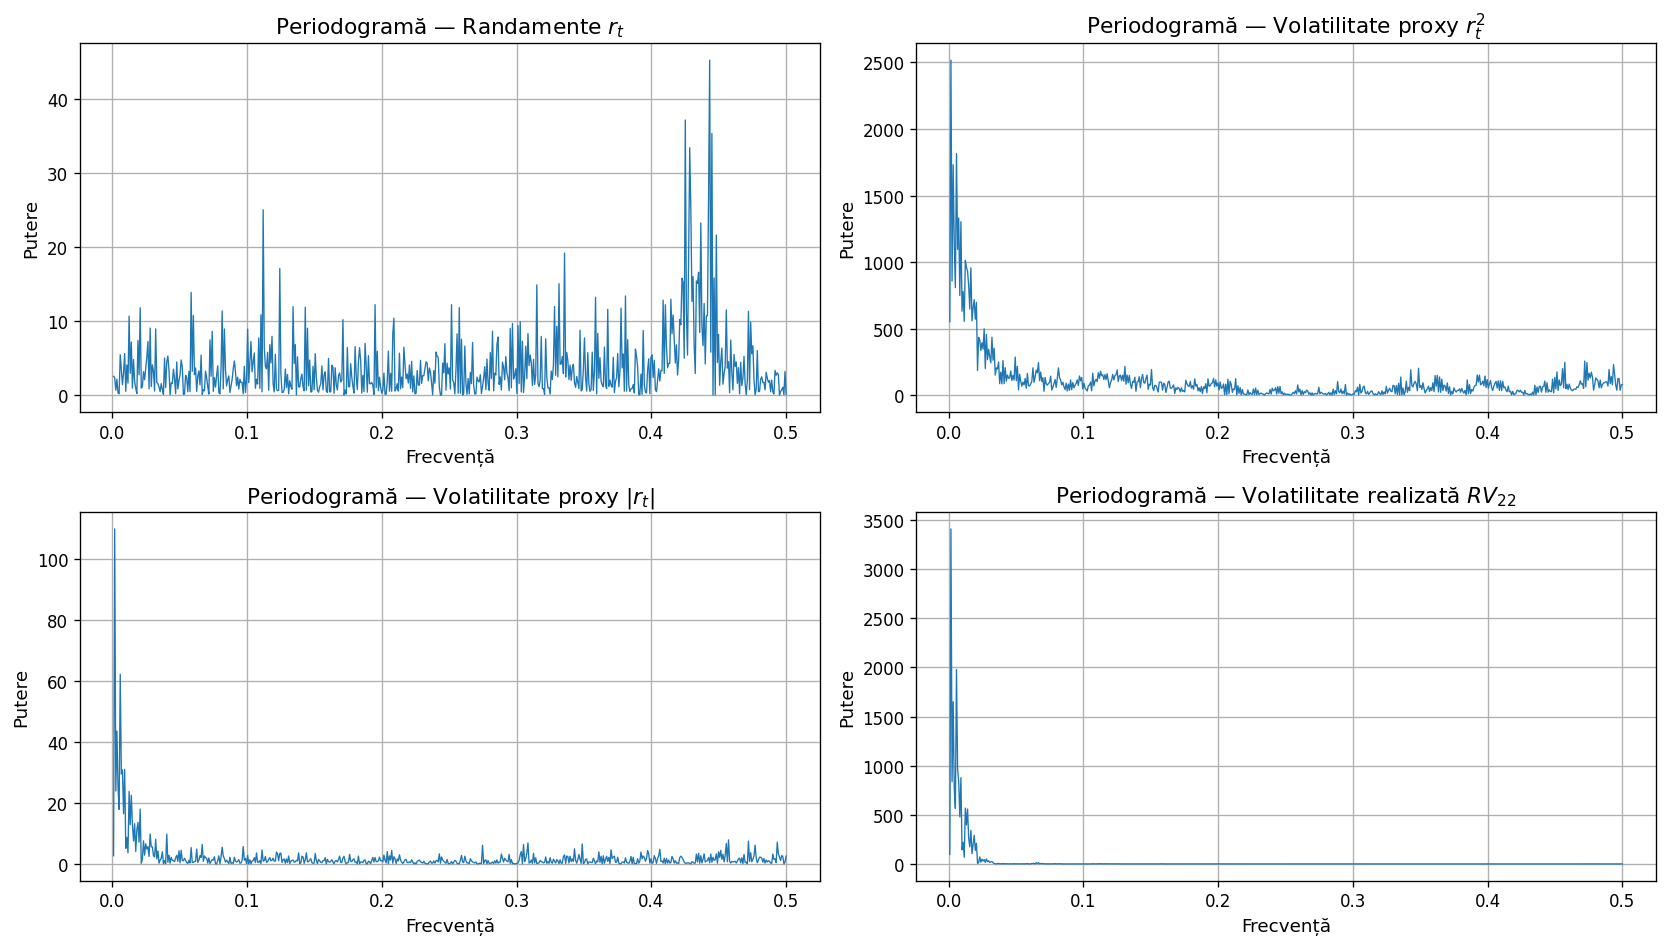

In [28]:
# ------------------------------------------------------------
# 3.9 SPECTRAL ANALYSIS
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

spectral_specs = [
    ('r_t', 'Randamente $r_t$'),
    ('r_t_sq', 'Volatilitate proxy $r_t^2$'),
    ('abs_r_t', 'Volatilitate proxy $|r_t|$'),
    ('rv_22d', 'Volatilitate realizată $RV_{22}$'),
]

for ax, (col, title) in zip(axes.flat, spectral_specs):
    x = train[col].dropna()
    x = x - x.mean()
    freq, power = periodogram(x)
    ax.plot(freq[1:], power[1:], linewidth=0.8)
    ax.set_title(f'Periodogramă — {title}')
    ax.set_xlabel('Frecvență')
    ax.set_ylabel('Putere')

plt.tight_layout()
plt.savefig(FIG_DIR / '16_periodograms.png', dpi=150, bbox_inches='tight')
plt.show()

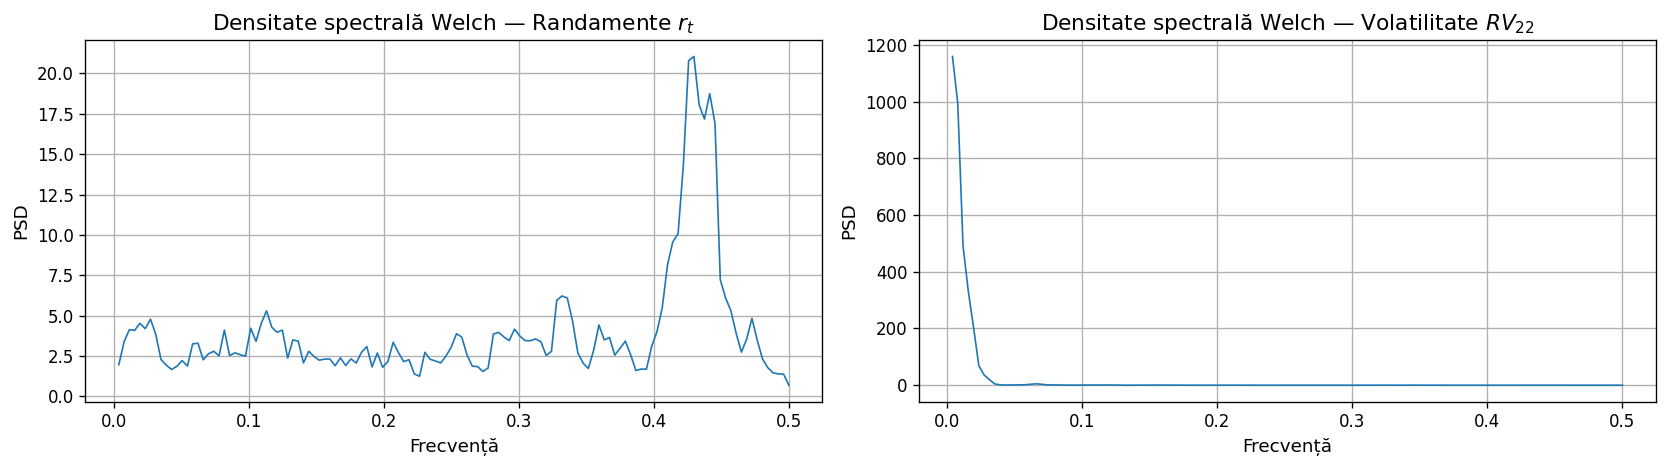

In [30]:
# Welch PSD — mai neted decât periodograma simplă
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['r_t', 'rv_22d'],
    ['Randamente $r_t$', 'Volatilitate $RV_{22}$']
):
    x = train[col].dropna()
    x = x - x.mean()
    x_np = x.to_numpy()

    freq, power = welch(
        x_np,
        nperseg=max(8, min(256, len(x_np) // 2))
    )

    ax.plot(freq[1:], power[1:], linewidth=1.0)
    ax.set_title(f'Densitate spectrală Welch — {title}')
    ax.set_xlabel('Frecvență')
    ax.set_ylabel('PSD')

plt.tight_layout()
plt.savefig(FIG_DIR / '17_welch_spectral_density.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.10. Modele neliniare: NNAR și SETAR

Testăm două alternative neliniare univariate:

- **NNAR**: rețea neuronală autoregresivă, implementată prin laguri și MLPRegressor;
- **SETAR**: model autoregresiv cu prag, în care dinamica depinde de regimul seriei.

Modelele sunt aplicate pe randamente și, separat, pe volatilitatea realizată $RV_{22}$.

In [32]:
# ------------------------------------------------------------
# 3.10 NNAR HELPERS
# ------------------------------------------------------------

def make_lagged_df(y, lags=5):
    y = pd.Series(y).dropna()
    data = pd.DataFrame({'y': y})
    for lag in range(1, lags + 1):
        data[f'lag_{lag}'] = y.shift(lag)
    return data.dropna()


def nnar_direct_forecast(y_train, y_test, lags=5, hidden_layer_sizes=(12,), random_state=42):
    """NNAR direct pe test: folosește laguri reale disponibile din seria concatenată.
    Pentru predicție out-of-sample strictă, la fiecare moment t folosim valori observate până la t-1.
    """
    y_all = pd.concat([y_train, y_test])
    lagged_all = make_lagged_df(y_all, lags=lags)
    lag_cols = [f'lag_{i}' for i in range(1, lags + 1)]

    train_idx = lagged_all.index.intersection(y_train.index)
    test_idx = lagged_all.index.intersection(y_test.index)

    X_train = lagged_all.loc[train_idx, lag_cols]
    y_train_model = lagged_all.loc[train_idx, 'y']
    X_test = lagged_all.loc[test_idx, lag_cols]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation='relu',
            solver='adam',
            max_iter=2000,
            random_state=random_state,
            early_stopping=True,
            n_iter_no_change=30
        ))
    ])
    model.fit(X_train, y_train_model)
    pred = pd.Series(model.predict(X_test), index=test_idx)
    return pred, model

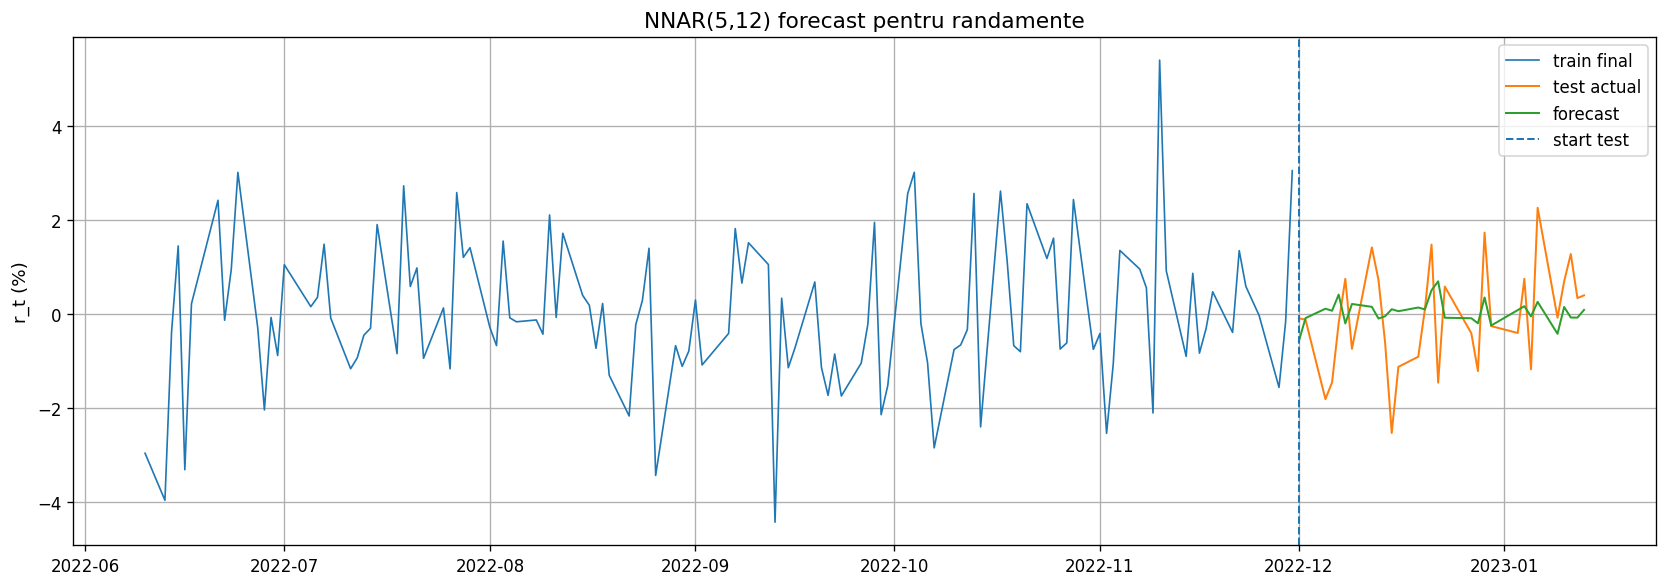

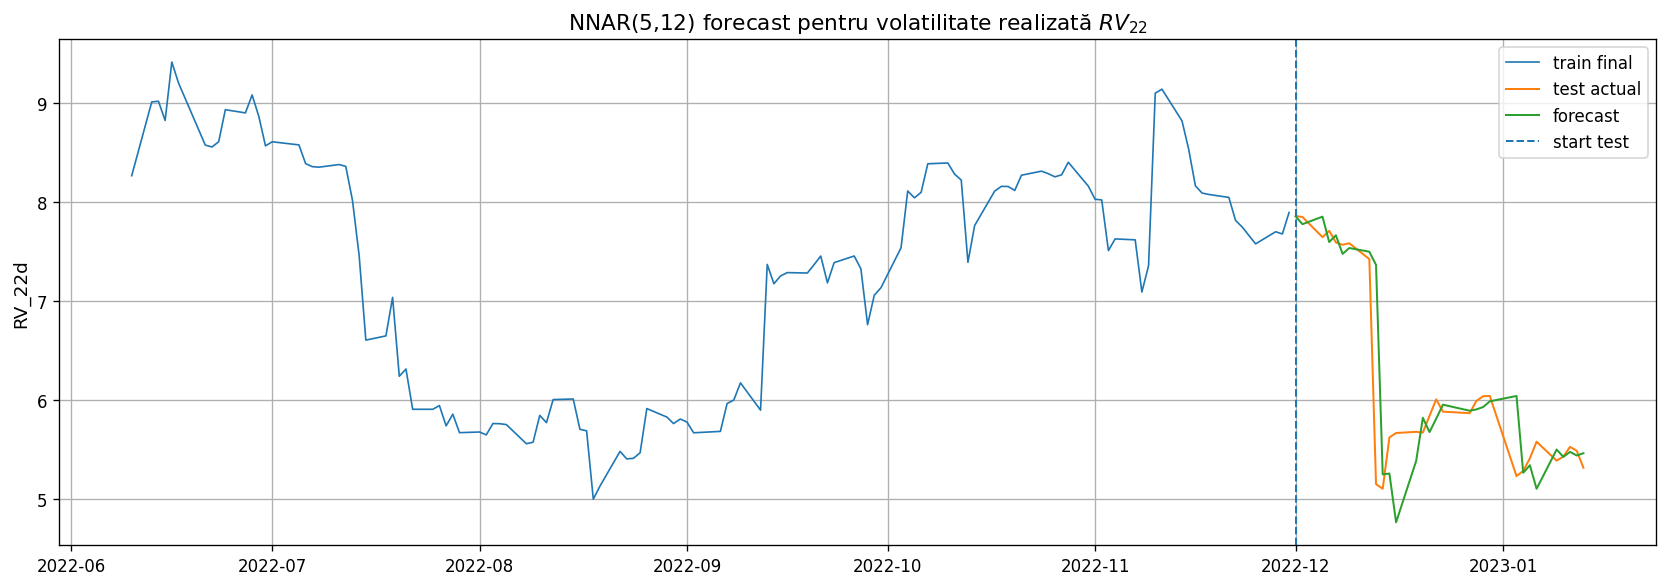

In [33]:
# NNAR pe randamente
try:
    nnar_ret_pred, nnar_ret_model = nnar_direct_forecast(r_train, r_test, lags=5, hidden_layer_sizes=(12,))
    returns_results.append(evaluate_point_forecast('NNAR(5,12) returns', r_test, nnar_ret_pred, 'r_t', 'NNAR'))

    plot_forecast(
        r_train, r_test, nnar_ret_pred,
        title='NNAR(5,12) forecast pentru randamente',
        ylabel='r_t (%)',
        filename='18_nnar_returns_forecast.png'
    )
except Exception as e:
    print('NNAR returns failed:', e)

# NNAR pe RV_22d
try:
    nnar_rv_pred, nnar_rv_model = nnar_direct_forecast(rv_train, rv_test, lags=5, hidden_layer_sizes=(12,))
    nnar_rv_pred = nnar_rv_pred.clip(lower=0)
    rv_results.append(evaluate_point_forecast('NNAR(5,12) RV_22d', rv_test, nnar_rv_pred, 'rv_22d', 'NNAR'))

    plot_forecast(
        rv_train, rv_test, nnar_rv_pred,
        title='NNAR(5,12) forecast pentru volatilitate realizată $RV_{22}$',
        ylabel='RV_22d',
        filename='19_nnar_rv_forecast.png'
    )
except Exception as e:
    print('NNAR RV failed:', e)

In [34]:
# ------------------------------------------------------------
# 3.10 SETAR HELPERS
# ------------------------------------------------------------

def fit_setar_1(y, delay=1, trim=0.15):
    """SETAR simplu cu două regimuri și AR(1) în fiecare regim."""
    y = pd.Series(y).dropna()
    data = pd.DataFrame({'y': y, 'threshold_var': y.shift(delay), 'lag1': y.shift(1)}).dropna()

    lo, hi = data['threshold_var'].quantile([trim, 1-trim])
    thresholds = np.linspace(lo, hi, 50)

    best = None
    for th in thresholds:
        low = data[data['threshold_var'] <= th]
        high = data[data['threshold_var'] > th]
        if len(low) < 30 or len(high) < 30:
            continue

        X_low = np.column_stack([np.ones(len(low)), low['lag1'].values])
        X_high = np.column_stack([np.ones(len(high)), high['lag1'].values])
        beta_low = np.linalg.lstsq(X_low, low['y'].values, rcond=None)[0]
        beta_high = np.linalg.lstsq(X_high, high['y'].values, rcond=None)[0]
        pred_low = X_low @ beta_low
        pred_high = X_high @ beta_high
        sse = np.sum((low['y'].values - pred_low)**2) + np.sum((high['y'].values - pred_high)**2)

        if best is None or sse < best['sse']:
            best = {
                'threshold': th,
                'beta_low': beta_low,
                'beta_high': beta_high,
                'sse': sse,
                'delay': delay,
                'n_low': len(low),
                'n_high': len(high),
            }
    return best


def predict_setar_1(y_train, y_test, model):
    y_all = pd.concat([y_train, y_test])
    preds = []
    idxs = []
    th = model['threshold']
    delay = model['delay']
    for t in y_test.index:
        pos = y_all.index.get_loc(t)
        if pos < max(1, delay):
            continue
        lag1 = y_all.iloc[pos-1]
        threshold_var = y_all.iloc[pos-delay]
        beta = model['beta_low'] if threshold_var <= th else model['beta_high']
        pred = beta[0] + beta[1] * lag1
        preds.append(pred)
        idxs.append(t)
    return pd.Series(preds, index=idxs)

SETAR returns model: {'threshold': np.float64(0.47063098341725307), 'beta_low': array([-0.03606947, -0.17966213]), 'beta_high': array([ 0.62131341, -0.50735206]), 'sse': np.float64(2230.497249344291), 'delay': 1, 'n_low': 828, 'n_high': 387}


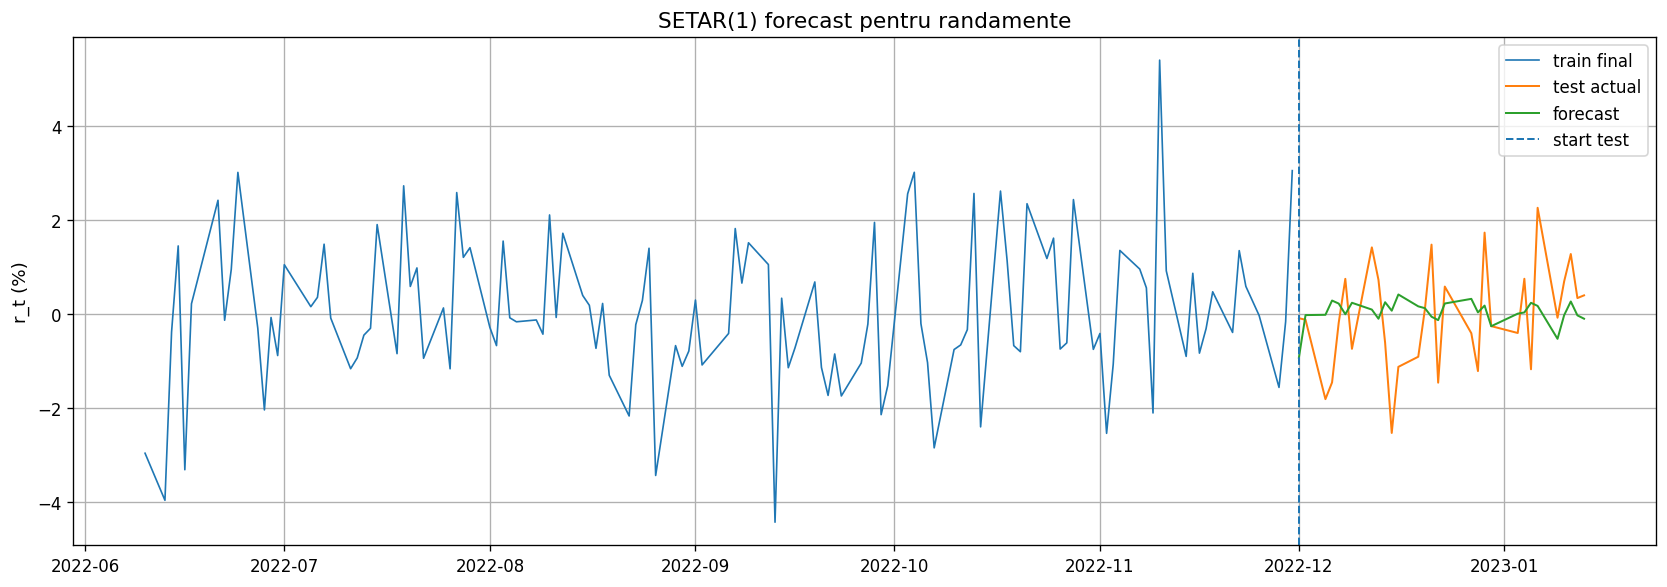

SETAR RV model: {'threshold': np.float64(3.0923156055114385), 'beta_low': array([0.20415697, 0.92394533]), 'beta_high': array([0.03457881, 0.99443175]), 'sse': np.float64(187.60566901499035), 'delay': 1, 'n_low': 313, 'n_high': 902}


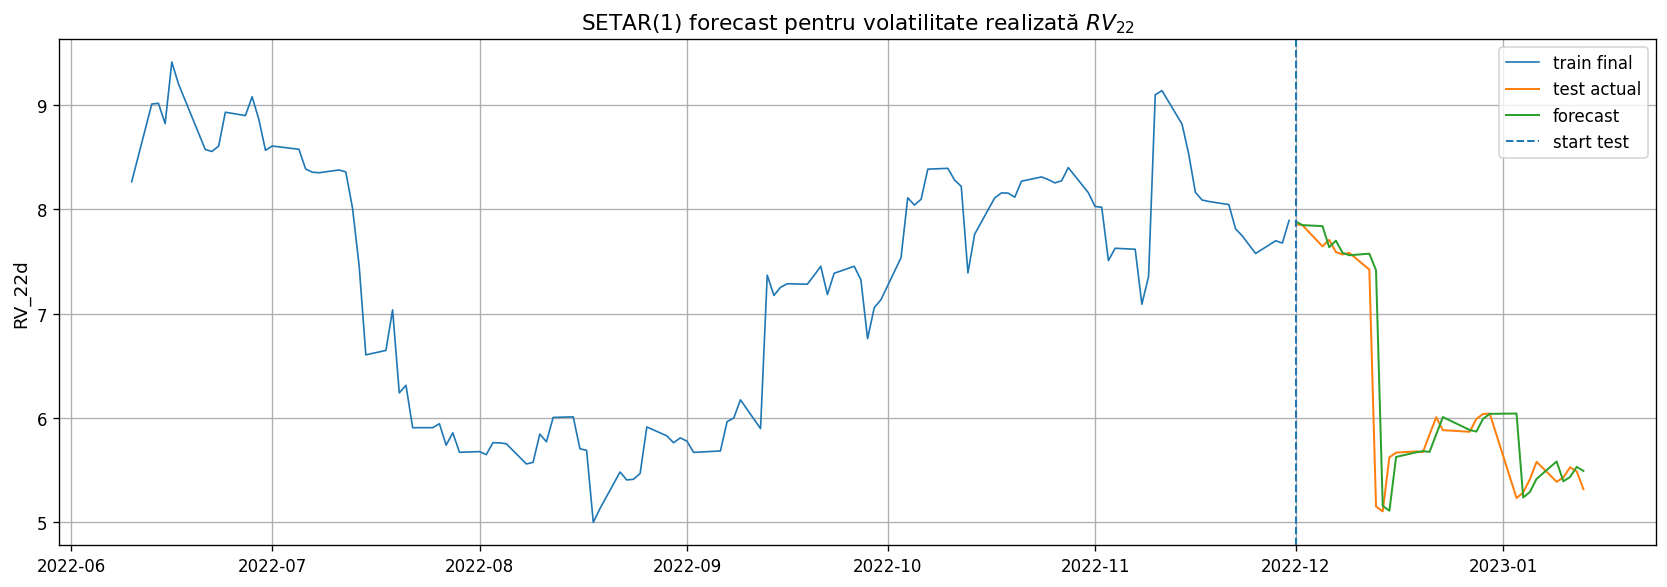

In [35]:
# SETAR pe randamente
try:
    setar_ret_model = fit_setar_1(r_train, delay=1)
    print('SETAR returns model:', setar_ret_model)
    if setar_ret_model is not None:
        setar_ret_pred = predict_setar_1(r_train, r_test, setar_ret_model)
        returns_results.append(evaluate_point_forecast('SETAR(1) returns', r_test, setar_ret_pred, 'r_t', 'SETAR'))

        plot_forecast(
            r_train, r_test, setar_ret_pred,
            title='SETAR(1) forecast pentru randamente',
            ylabel='r_t (%)',
            filename='20_setar_returns_forecast.png'
        )
except Exception as e:
    print('SETAR returns failed:', e)

# SETAR pe RV_22d
try:
    setar_rv_model = fit_setar_1(rv_train, delay=1)
    print('SETAR RV model:', setar_rv_model)
    if setar_rv_model is not None:
        setar_rv_pred = predict_setar_1(rv_train, rv_test, setar_rv_model).clip(lower=0)
        rv_results.append(evaluate_point_forecast('SETAR(1) RV_22d', rv_test, setar_rv_pred, 'rv_22d', 'SETAR'))

        plot_forecast(
            rv_train, rv_test, setar_rv_pred,
            title='SETAR(1) forecast pentru volatilitate realizată $RV_{22}$',
            ylabel='RV_22d',
            filename='21_setar_rv_forecast.png'
        )
except Exception as e:
    print('SETAR RV failed:', e)

## 3.11. Compararea performanței predictive

Comparăm modelele separat, deoarece au ținte diferite:

1. modele pentru **randamente**;
2. modele pentru **preț**;
3. modele pentru **volatilitate realizată**;
4. modele GARCH pentru **varianță condițională**, evaluată față de $r_t^2$.

Nu comparăm direct RMSE-ul între ținte diferite.

In [36]:
# ------------------------------------------------------------
# 3.11 RESULTS TABLES
# ------------------------------------------------------------

returns_results_df = pd.DataFrame(returns_results).sort_values('RMSE').reset_index(drop=True)
price_results_df = pd.DataFrame(price_results).sort_values('RMSE').reset_index(drop=True)
rv_results_df = pd.DataFrame(rv_results).sort_values('RMSE').reset_index(drop=True)
garch_results_df = pd.DataFrame(garch_results).sort_values('QLIKE').reset_index(drop=True) if len(garch_results) > 0 else pd.DataFrame()
model_info_df = pd.DataFrame(model_info)

returns_results_df.to_csv(TABLE_DIR / '09_returns_forecast_comparison.csv', index=False)
price_results_df.to_csv(TABLE_DIR / '10_price_forecast_comparison.csv', index=False)
rv_results_df.to_csv(TABLE_DIR / '11_rv_forecast_comparison.csv', index=False)
if len(garch_results_df) > 0:
    garch_results_df.to_csv(TABLE_DIR / '12_garch_variance_forecast_comparison.csv', index=False)
if len(model_info_df) > 0:
    model_info_df.to_csv(TABLE_DIR / '13_model_information_criteria.csv', index=False)

print('=== Modele pentru randamente ===')
display(returns_results_df.round(6))

print('=== Modele pentru preț ===')
display(price_results_df.round(6))

print('=== Modele pentru volatilitate realizată RV_22d ===')
display(rv_results_df.round(6))

print('=== Modele GARCH pentru varianță condițională ===')
display(garch_results_df.round(6) if len(garch_results_df) > 0 else 'No GARCH results')

=== Modele pentru randamente ===


,model,family,target,n_test,MAE,RMSE,MAPE,R2,QLIKE
0,Mean forecast,Benchmark,r_t,522,0.631190,0.827919,124.506796,-0.002406,NaN
1,Zero return forecast,Benchmark,r_t,522,0.633541,0.829957,100.000000,-0.007348,NaN
2,"ARIMA(4, 0, 2)",ARIMA,r_t,522,0.632842,0.830071,125.074905,-0.007624,NaN
3,"SARIMA(4, 0, 2)x(1, 0, 1, 5)",SARIMA,r_t,522,0.636547,0.832223,102.531955,-0.012855,NaN
4,SETAR(1) returns,SETAR,r_t,522,0.649330,0.842729,180.459221,-0.038590,NaN
5,"NNAR(5,12) returns",NNAR,r_t,522,0.647009,0.843315,165.744398,-0.040034,NaN
6,Naive last value,Benchmark,r_t,522,2.976982,3.089697,4048.483086,-12.960469,NaN


=== Modele pentru preț ===


,model,family,target,n_test,MAE,RMSE,MAPE,R2,QLIKE
0,State Space local linear trend price,State Space,adj_close,522,471.088157,617.528708,8.905993,0.129437,NaN
1,Holt additive trend price,ETS,adj_close,522,523.696857,687.952814,9.880783,-0.080446,NaN
2,ETS additive trend price,ETS,adj_close,522,523.696857,687.952814,9.880783,-0.080446,NaN
3,Random Walk price,Benchmark,adj_close,522,773.067199,991.407886,14.628092,-1.243832,NaN


=== Modele pentru volatilitate realizată RV_22d ===


,model,family,target,n_test,MAE,RMSE,MAPE,R2,QLIKE
0,SETAR(1) RV_22d,SETAR,rv_22d,522,0.126089,0.218731,3.442263,0.957970,NaN
1,"NNAR(5,12) RV_22d",NNAR,rv_22d,522,0.170072,0.253494,4.696479,0.943549,NaN
2,SES RV_22d,ETS,rv_22d,522,4.057485,4.195414,120.665775,-14.462744,NaN
3,State Space local level RV_22d,State Space,rv_22d,522,4.057485,4.195414,120.665775,-14.462744,NaN
4,Naive RV forecast,Benchmark,rv_22d,522,4.057485,4.195414,120.665775,-14.462744,NaN
5,Holt RV_22d,ETS,rv_22d,522,6.606178,6.937781,195.909105,-41.284194,NaN


=== Modele GARCH pentru varianță condițională ===


,model,family,target,n_test,MAE,RMSE,MAPE,R2,QLIKE
0,"EGARCH(1,1)-t",GARCH,r_t_sq,522,1.584590,1.802665,NaN,-1.695534,1.033554
1,"GJR-GARCH(1,1)-t",GARCH,r_t_sq,522,1.647170,1.794221,NaN,-1.670339,1.069519
2,ARCH(1),GARCH,r_t_sq,522,1.762201,1.909981,NaN,-2.026028,1.112068
3,"GARCH(1,1)",GARCH,r_t_sq,522,2.503991,2.621284,NaN,-4.699577,1.345688
4,"GARCH(1,1)-t",GARCH,r_t_sq,522,10.171745,11.236991,NaN,-103.740510,2.364069


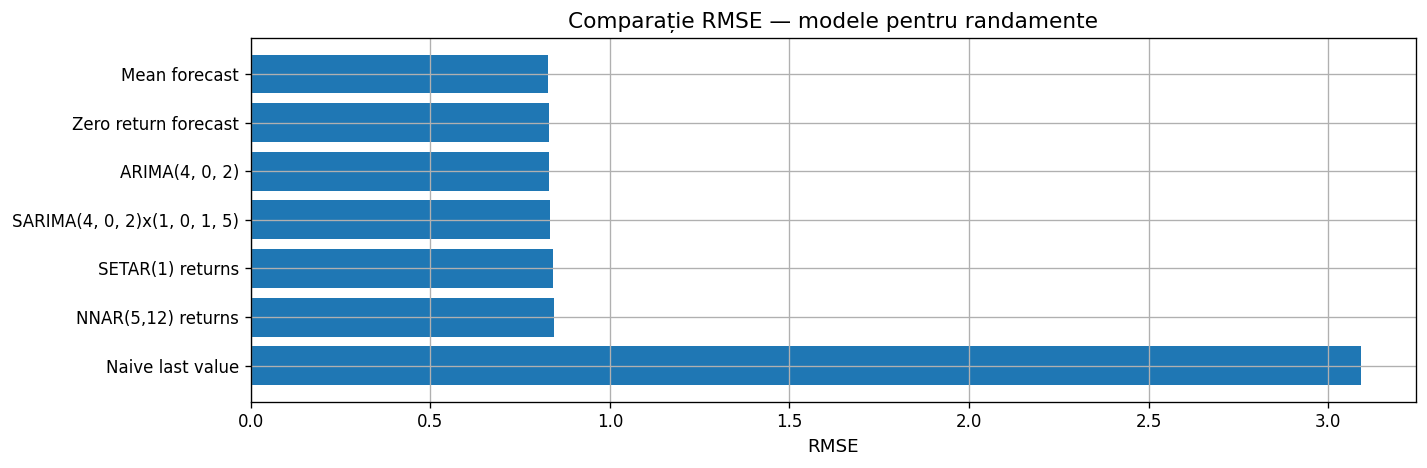

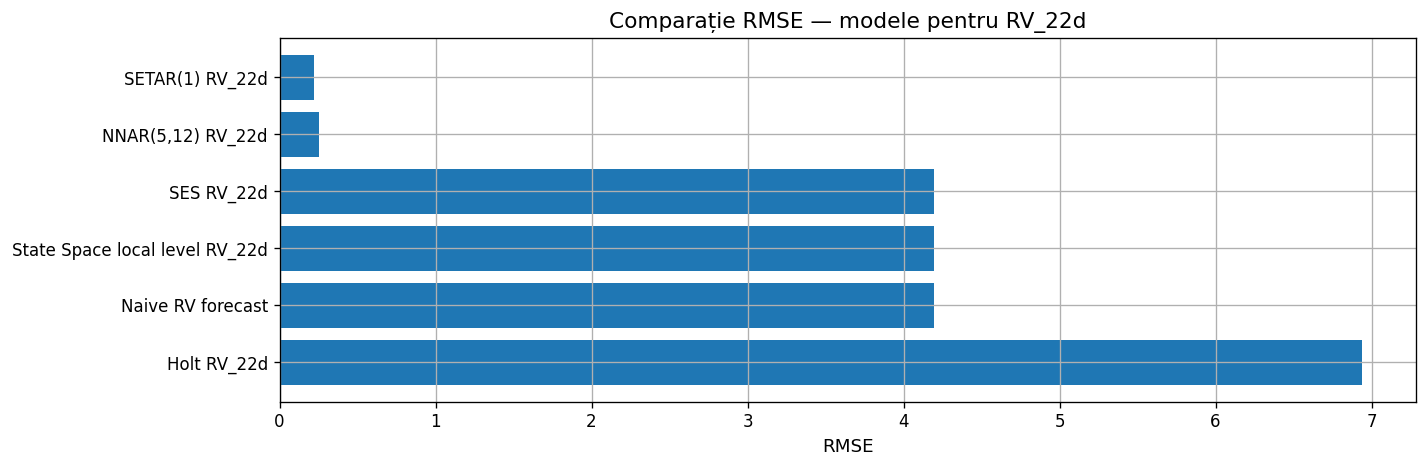

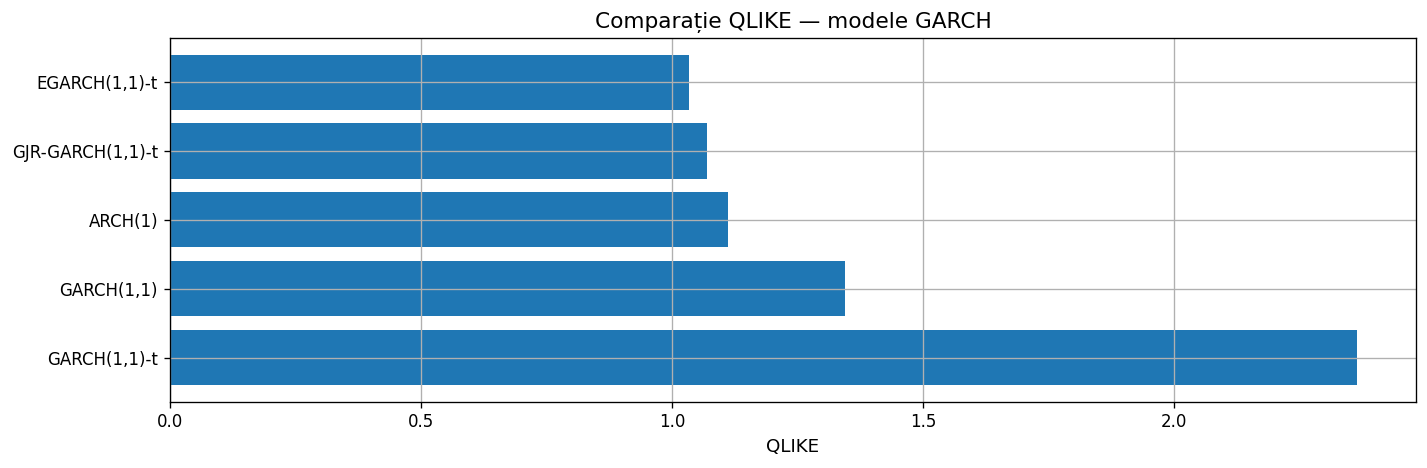

In [37]:
# ------------------------------------------------------------
# RESULTS PLOTS
# ------------------------------------------------------------

def plot_metric_table(df_res, metric, title, filename):
    if df_res is None or len(df_res) == 0 or metric not in df_res.columns:
        return
    plot_df = df_res.sort_values(metric, ascending=True).copy()
    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(plot_df))))
    ax.barh(plot_df['model'], plot_df[metric])
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_metric_table(returns_results_df, 'RMSE', 'Comparație RMSE — modele pentru randamente', '22_rmse_returns_models.png')
plot_metric_table(rv_results_df, 'RMSE', 'Comparație RMSE — modele pentru RV_22d', '23_rmse_rv_models.png')
if len(garch_results_df) > 0:
    plot_metric_table(garch_results_df, 'QLIKE', 'Comparație QLIKE — modele GARCH', '24_qlike_garch_models.png')

### Testul Diebold-Mariano

Testul Diebold-Mariano compară acuratețea predictivă a două modele pe aceeași țintă și aceeași perioadă de test.

Aplicăm testul doar pentru comparații rezonabile:

- cel mai bun model pentru randamente vs. zero forecast / naive forecast;
- cel mai bun model pentru RV vs. benchmark RV;
- cel mai bun GARCH vs. alt model GARCH, dacă există suficiente rezultate.

In [38]:
# ------------------------------------------------------------
# DIEBOLD-MARIANO TEST
# ------------------------------------------------------------

def diebold_mariano(y_true, pred_1, pred_2, loss='squared', h=1):
    """DM test simplu pentru h=1. H0: aceeași acuratețe predictivă."""
    y_true = pd.Series(y_true).dropna()
    pred_1 = pd.Series(pred_1).dropna()
    pred_2 = pd.Series(pred_2).dropna()
    idx = y_true.index.intersection(pred_1.index).intersection(pred_2.index)
    y = y_true.loc[idx]
    p1 = pred_1.loc[idx]
    p2 = pred_2.loc[idx]

    e1 = y - p1
    e2 = y - p2

    if loss == 'absolute':
        d = np.abs(e1) - np.abs(e2)
    elif loss == 'squared':
        d = e1**2 - e2**2
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    d = d.dropna()
    n = len(d)
    if n < 5 or d.std(ddof=1) == 0:
        return {'DM_stat': np.nan, 'p_value': np.nan, 'n': n}

    dm_stat = d.mean() / np.sqrt(d.var(ddof=1) / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return {'DM_stat': dm_stat, 'p_value': p_value, 'n': n, 'mean_loss_diff': d.mean()}

# Colectăm predicții principale pentru DM
pred_store = {
    'Zero return forecast': zero_ret_pred,
    'Naive last value': naive_ret_pred,
    f'ARIMA{best_arima_order}': arima_pred,
}
if 'nnar_ret_pred' in globals():
    pred_store['NNAR(5,12) returns'] = nnar_ret_pred
if 'setar_ret_pred' in globals() and setar_ret_pred is not None:
    pred_store['SETAR(1) returns'] = setar_ret_pred

# Best returns model după RMSE
best_returns_model = returns_results_df.iloc[0]['model'] if len(returns_results_df) > 0 else None

# Teste DM pentru randamente: best vs zero, best vs naive, ARIMA vs zero
DM_rows = []
comparisons = []
if best_returns_model in pred_store:
    comparisons.extend([
        (best_returns_model, 'Zero return forecast'),
        (best_returns_model, 'Naive last value'),
    ])
comparisons.append((f'ARIMA{best_arima_order}', 'Zero return forecast'))

for m1, m2 in comparisons:
    if m1 in pred_store and m2 in pred_store and m1 != m2:
        res = diebold_mariano(r_test, pred_store[m1], pred_store[m2], loss='squared', h=1)
        res.update({'target': 'r_t', 'model_1': m1, 'model_2': m2, 'loss': 'squared'})
        DM_rows.append(res)

# DM pentru RV, dacă avem predicții
rv_pred_store = {'Naive RV forecast': naive_rv_pred}
if 'ses_rv_pred' in globals():
    rv_pred_store['SES RV_22d'] = ses_rv_pred
if 'holt_rv_pred' in globals():
    rv_pred_store['Holt RV_22d'] = holt_rv_pred
if 'ss_rv_pred' in globals():
    rv_pred_store['State Space local level RV_22d'] = ss_rv_pred
if 'nnar_rv_pred' in globals():
    rv_pred_store['NNAR(5,12) RV_22d'] = nnar_rv_pred
if 'setar_rv_pred' in globals() and setar_rv_pred is not None:
    rv_pred_store['SETAR(1) RV_22d'] = setar_rv_pred

best_rv_model = rv_results_df.iloc[0]['model'] if len(rv_results_df) > 0 else None
if best_rv_model in rv_pred_store and best_rv_model != 'Naive RV forecast':
    res = diebold_mariano(rv_test, rv_pred_store[best_rv_model], rv_pred_store['Naive RV forecast'], loss='squared', h=1)
    res.update({'target': 'rv_22d', 'model_1': best_rv_model, 'model_2': 'Naive RV forecast', 'loss': 'squared'})
    DM_rows.append(res)

dm_df = pd.DataFrame(DM_rows)
if len(dm_df) > 0:
    dm_df['decision_5pct'] = np.where(dm_df['p_value'] < 0.05, 'different accuracy', 'no significant difference')
    dm_df.to_csv(TABLE_DIR / '14_diebold_mariano_tests.csv', index=False)

dm_df.round(6) if len(dm_df) > 0 else 'No DM tests available'

,DM_stat,p_value,n,mean_loss_diff,target,model_1,model_2,loss,decision_5pct
0,0.045630,0.963605,522,0.000189,r_t,"ARIMA(4, 0, 2)",Zero return forecast,squared,no significant difference
1,-52.096216,0.000000,522,-17.553658,rv_22d,SETAR(1) RV_22d,Naive RV forecast,squared,different accuracy


## Sumar automat pentru interpretare

Această celulă extrage rezultatele principale, astfel încât să fie ușor de transpus în raportul Word.

In [39]:
# ------------------------------------------------------------
# AUTOMATIC SUMMARY
# ------------------------------------------------------------

print('================ NOTEBOOK 02 SUMMARY ================')
print(f"Perioadă totală: {series.index.min().date()} → {series.index.max().date()} | n={len(series):,}")
print(f"Train: {train.index.min().date()} → {train.index.max().date()} | n={len(train):,}")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} | n={len(test):,}")
print('\n--- Staționaritate ---')
for col in ['r_t', 'r_t_sq', 'abs_r_t', 'rv_22d']:
    if col in stationarity_df.index:
        print(f"{col}: ADF={stationarity_df.loc[col, 'ADF_decision_5pct']}, KPSS={stationarity_df.loc[col, 'KPSS_decision_5pct']}")

print('\n--- ARCH-LM ---')
print(arch_lm_df[['LM_pvalue', 'decision_5pct']].to_string(index=False))

print('\n--- Best returns model by RMSE ---')
if len(returns_results_df) > 0:
    print(returns_results_df.iloc[0][['model', 'RMSE', 'MAE', 'R2']].to_string())

print('\n--- Best RV model by RMSE ---')
if len(rv_results_df) > 0:
    print(rv_results_df.iloc[0][['model', 'RMSE', 'MAE', 'R2']].to_string())

print('\n--- Best GARCH model by QLIKE ---')
if len(garch_results_df) > 0:
    print(garch_results_df.iloc[0][['model', 'QLIKE', 'RMSE', 'MAE']].to_string())

print('\nTabele salvate în:', TABLE_DIR)
print('Grafice salvate în:', FIG_DIR)

================ NOTEBOOK 02 SUMMARY ================
Perioadă totală: 2018-02-02 → 2024-12-30 | n=1,738
Train: 2018-02-02 → 2022-11-30 | n=1,216
Test:  2022-12-01 → 2024-12-30 | n=522

--- Staționaritate ---
r_t: ADF=stationary, KPSS=stationary
r_t_sq: ADF=stationary, KPSS=stationary
abs_r_t: ADF=stationary, KPSS=stationary
rv_22d: ADF=non-stationary, KPSS=stationary

--- ARCH-LM ---
   LM_pvalue decision_5pct
1.443204e-97  ARCH effects

--- Best returns model by RMSE ---
model    Mean forecast
RMSE          0.827919
MAE            0.63119
R2           -0.002406

--- Best RV model by RMSE ---
model    SETAR(1) RV_22d
RMSE            0.218731
MAE             0.126089
R2               0.95797

--- Best GARCH model by QLIKE ---
model    EGARCH(1,1)-t
QLIKE         1.033554
RMSE          1.802665
MAE            1.58459

Tabele salvate în: data\tables\notebook_02
Grafice salvate în: data\figures\notebook_02


## Concluzii de completat după rulare

După rulare, se interpretează:

1. dacă nivelul indicelui este non-staționar, iar randamentele sunt staționare;
2. dacă ACF/PACF indică autocorelație slabă în randamente, dar persistență în volatilitate;
3. dacă ARCH-LM confirmă nevoia de modele GARCH;
4. dacă ARIMA aduce îmbunătățiri față de benchmark-urile simple;
5. care model GARCH are cel mai bun AIC/BIC și care are cea mai bună prognoză out-of-sample;
6. dacă State Space, NNAR sau SETAR aduc valoare față de benchmark;
7. care model devine benchmark-ul principal pentru comparația cu modelele ce includ sentimentul în notebook-urile următoare.